## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [183]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 sklearn-pandas==2.2.0 -q --user

In [184]:
pip install pgeocode

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.


**Required Libraries for Business Problem**

In [185]:
# to load and manipulate data
import pandas as pd
import numpy as np

#to map zipcodes
import pgeocode

# to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# to split data into training and test sets
from sklearn.model_selection import train_test_split

# to build decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# to tune different models
from sklearn.model_selection import GridSearchCV

# to compute classification metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
)

## Loading the dataset

In [186]:
# Mounting Google Drive to access source dataset stored in the Drive from this Colab environment for performing the data analysis
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [187]:
print("✅ Reading the source CSV file from the AllLife Bank to understand the customer attributes... starting the journey of a Data Scientist!")
data = pd.read_csv('/content/drive/MyDrive/MachineLearning/Loan_Modelling.csv')

✅ Reading the source CSV file from the AllLife Bank to understand the customer attributes... starting the journey of a Data Scientist!


In [188]:
# Creating a copy of the data as the raw dataset is your source of truth before we impute data for further analysis
customer_attributes_data = data.copy()

## Data Overview

* Observations
* Sanity checks

**Exploring data and generating observations**

Previewing Data for first and last few rows

In [189]:
## Veiwing the first 10 rows of data
customer_attributes_data.head(10)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
5,6,37,13,29,92121,4,0.4,2,155,0,0,0,1,0
6,7,53,27,72,91711,2,1.5,2,0,0,0,0,1,0
7,8,50,24,22,93943,1,0.3,3,0,0,0,0,0,1
8,9,35,10,81,90089,3,0.6,2,104,0,0,0,1,0
9,10,34,9,180,93023,1,8.9,3,0,1,0,0,0,0


In [190]:
## Veiwing the first 10 rows of data
customer_attributes_data.tail(10)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4990,4991,55,25,58,95023,4,2.00,3,219,0,0,0,0,1
4991,4992,51,25,92,91330,1,1.90,2,100,0,0,0,0,1
4992,4993,30,5,13,90037,4,0.50,3,0,0,0,0,0,0
4993,4994,45,21,218,91801,2,6.67,1,0,0,0,0,1,0
4994,4995,64,40,75,94588,3,2.00,3,0,0,0,0,1,0
4995,4996,29,3,40,92697,1,1.90,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.40,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.30,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.50,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.80,1,0,0,0,0,1,1


Check column names

In [191]:
## Column names
pd.DataFrame(customer_attributes_data.columns, columns=['Column Name'])

,Column Name
0,ID
1,Age
2,Experience
3,Income
4,ZIPCode
5,Family
6,CCAvg
7,Education
8,Mortgage
9,Personal_Loan


Data types of each column

In [192]:
pd.DataFrame(customer_attributes_data.dtypes, columns=['DataTypes'])

,DataTypes
ID,int64
Age,int64
Experience,int64
Income,int64
ZIPCode,int64
Family,int64
CCAvg,float64
Education,int64
Mortgage,int64
Personal_Loan,int64


Quick info summary though datatypes are viewed above , to view
*   non-null counts
*   total number of entry records
*   index range
*   number of columns in the dataset
*   index range
*   memory usage

In [193]:
customer_attributes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


**Data Sanity Checks**

Perform various sanity checks on the customer_attributes_data DataFrame, including checking for duplicate rows, analyzing unique values in categorical columns, and validating the consistency of 'Age' and 'Experience' columns.We are going to eliminate data sanity check for ID column.

ID is just a unique identifier: It doesn’t carry any predictive information about whether a customer accepts a personal loan. It’s simply a label to distinguish rows.

In [194]:
### identifying number of duplicate rows
print(f"Number of duplicate rows: {customer_attributes_data.duplicated().sum()}\n")


Number of duplicate rows: 0



In [195]:
# Check unique values and their counts for categorical columns
categorical_cols = ['Education', 'Family', 'Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard']
print("Unique values and counts for categorical columns:")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(customer_attributes_data[col].value_counts())
    print(f"Number of unique values in {col}: {customer_attributes_data[col].nunique()}")

Unique values and counts for categorical columns:

--- Education ---
Education
1    2096
3    1501
2    1403
Name: count, dtype: int64
Number of unique values in Education: 3

--- Family ---
Family
1    1472
2    1296
4    1222
3    1010
Name: count, dtype: int64
Number of unique values in Family: 4

--- Personal_Loan ---
Personal_Loan
0    4520
1     480
Name: count, dtype: int64
Number of unique values in Personal_Loan: 2

--- Securities_Account ---
Securities_Account
0    4478
1     522
Name: count, dtype: int64
Number of unique values in Securities_Account: 2

--- CD_Account ---
CD_Account
0    4698
1     302
Name: count, dtype: int64
Number of unique values in CD_Account: 2

--- Online ---
Online
1    2984
0    2016
Name: count, dtype: int64
Number of unique values in Online: 2

--- CreditCard ---
CreditCard
0    3530
1    1470
Name: count, dtype: int64
Number of unique values in CreditCard: 2


In [196]:
# Check unique values for ZIPCode (high cardinality, just show number of unique values)
print(f"\nNumber of unique ZIP Codes: {customer_attributes_data['ZIPCode'].nunique()}")


Number of unique ZIP Codes: 467


In [197]:
##Below function checks a specified DataFrame column for negative values, reports the count, and shows up to 5 sample rows.
def check_negative_values(df, column_name):
    """
    Check for negative values in a given column of a DataFrame.
    Prints the count and shows a sample of up to 5 rows if negatives exist.
    """
    # Filter rows with negative values
    negative_rows = df[df[column_name] < 0]

    # Count negatives
    count_negatives = (df[column_name] < 0).sum()

    print(f"Count of negative values in '{column_name}':", count_negatives)

    # Show sample if negatives exist
    if count_negatives > 0:
        print(f"Sample of rows with negative '{column_name}':\n",
              negative_rows.sample(n=min(5, len(negative_rows))))


In [198]:
# Check Age column
check_negative_values(customer_attributes_data, "Age")

# Check Experience column
check_negative_values(customer_attributes_data, "Experience")

# Check Salary column (should show 0 negatives)
check_negative_values(customer_attributes_data, "Income")

# Check ZipCode column (should show 0 negatives)
check_negative_values(customer_attributes_data, "ZIPCode")

# Check CCAvg column (should show 0 negatives)
check_negative_values(customer_attributes_data, "CCAvg")

# Check Mortgage column (should show 0 negatives)
check_negative_values(customer_attributes_data, "Mortgage")


Count of negative values in 'Age': 0
Count of negative values in 'Experience': 52
Sample of rows with negative 'Experience':
         ID  Age  Experience  Income  ZIPCode  Family  CCAvg  Education  \
3284  3285   25          -1     101    95819       4    2.1          3   
649    650   25          -1      82    92677       4    2.1          3   
2962  2963   23          -2      81    91711       2    1.8          2   
315    316   24          -2      51    90630       3    0.3          3   
583    584   24          -1      38    95045       2    1.7          2   

      Mortgage  Personal_Loan  Securities_Account  CD_Account  Online  \
3284         0              0                   0           0       0   
649          0              0                   0           0       1   
2962         0              0                   0           0       0   
315          0              0                   0           0       1   
583          0              0                   0           0   

In [199]:
# Check where Experience is greater than Age
inconsistent_age_experience = customer_attributes_data[customer_attributes_data['Experience'] > customer_attributes_data['Age']]
print(f"Number of rows where Experience is greater than Age: {len(inconsistent_age_experience)}")
# Display some of these inconsistent rows if they exist
if not inconsistent_age_experience.empty:
    print("\nSample of rows where Experience > Age:")
    print(inconsistent_age_experience[['Age', 'Experience']].head())

Number of rows where Experience is greater than Age: 0


Banks in the U.S. generally require you to be at least 18 years old to qualify for a personal loan. This is because 18 is the legal age at which you can enter into binding contracts. Some lenders may set higher minimums (like 21) depending on state laws or their own policies, but 18 is the standard threshold.Since our problem statement doesn't mention any particular threshold, lets consider '18' as the minimum requirement

In [200]:
# Define the ideal adult age threshold
ideal_adult_age = 18

# Find entries where age is less than the ideal adult age
entries_age_less_than_adult = customer_attributes_data[customer_attributes_data['Age'] < ideal_adult_age]

print(f"Number of entries with age less than {ideal_adult_age}: {len(entries_age_less_than_adult)}")
if not entries_age_less_than_adult.empty:
    print(f"\nSample of entries with age less than {ideal_adult_age}:\n")
    print(entries_age_less_than_adult.head())
else:
    print(f"\nNo entries found with age less than {ideal_adult_age}.")

Number of entries with age less than 18: 0

No entries found with age less than 18.


### Observations:

There are no entries less than 18, and no entries with negative age, indicating age column is appropriate.*italicized text*

**Data Analysis Key Findings:**
1. There are no duplicate rows in the customer_attributes_data DataFrame.
2. The categorical columns (Education, Family, Personal_Loan, Securities_Account, CD_Account, Online, CreditCard) show expected binary or low-cardinality integer values (e.g., Education has 3 unique values, Family has 4 unique values).There are no unexpected values or negative entries.
3. The ZIPCode column has 467 unique values, indicating high cardinality, which is expected for postal codes.
4. There are 52 rows where 'Experience' is negative. A sample of these rows shows instances where Experience is negative. We need to handle these placeholder/missing values where experience is negative.
5.   Unique values and counts for categorical columns analysis namely zipcode, income, age,mortgage, ccAvg indicate that these columns doesn't have any negative values, unexpected entries.




## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

**Univariate Analysis Of Categorical Variables**


--- Value Counts for Education ---
Education
1    2096
3    1501
2    1403
Name: count, dtype: int64

--- Value Counts for Family ---
Family
1    1472
2    1296
4    1222
3    1010
Name: count, dtype: int64

--- Value Counts for Personal_Loan ---
Personal_Loan
0    4520
1     480
Name: count, dtype: int64

--- Value Counts for Securities_Account ---
Securities_Account
0    4478
1     522
Name: count, dtype: int64

--- Value Counts for CD_Account ---
CD_Account
0    4698
1     302
Name: count, dtype: int64

--- Value Counts for Online ---
Online
1    2984
0    2016
Name: count, dtype: int64

--- Value Counts for CreditCard ---
CreditCard
0    3530
1    1470
Name: count, dtype: int64


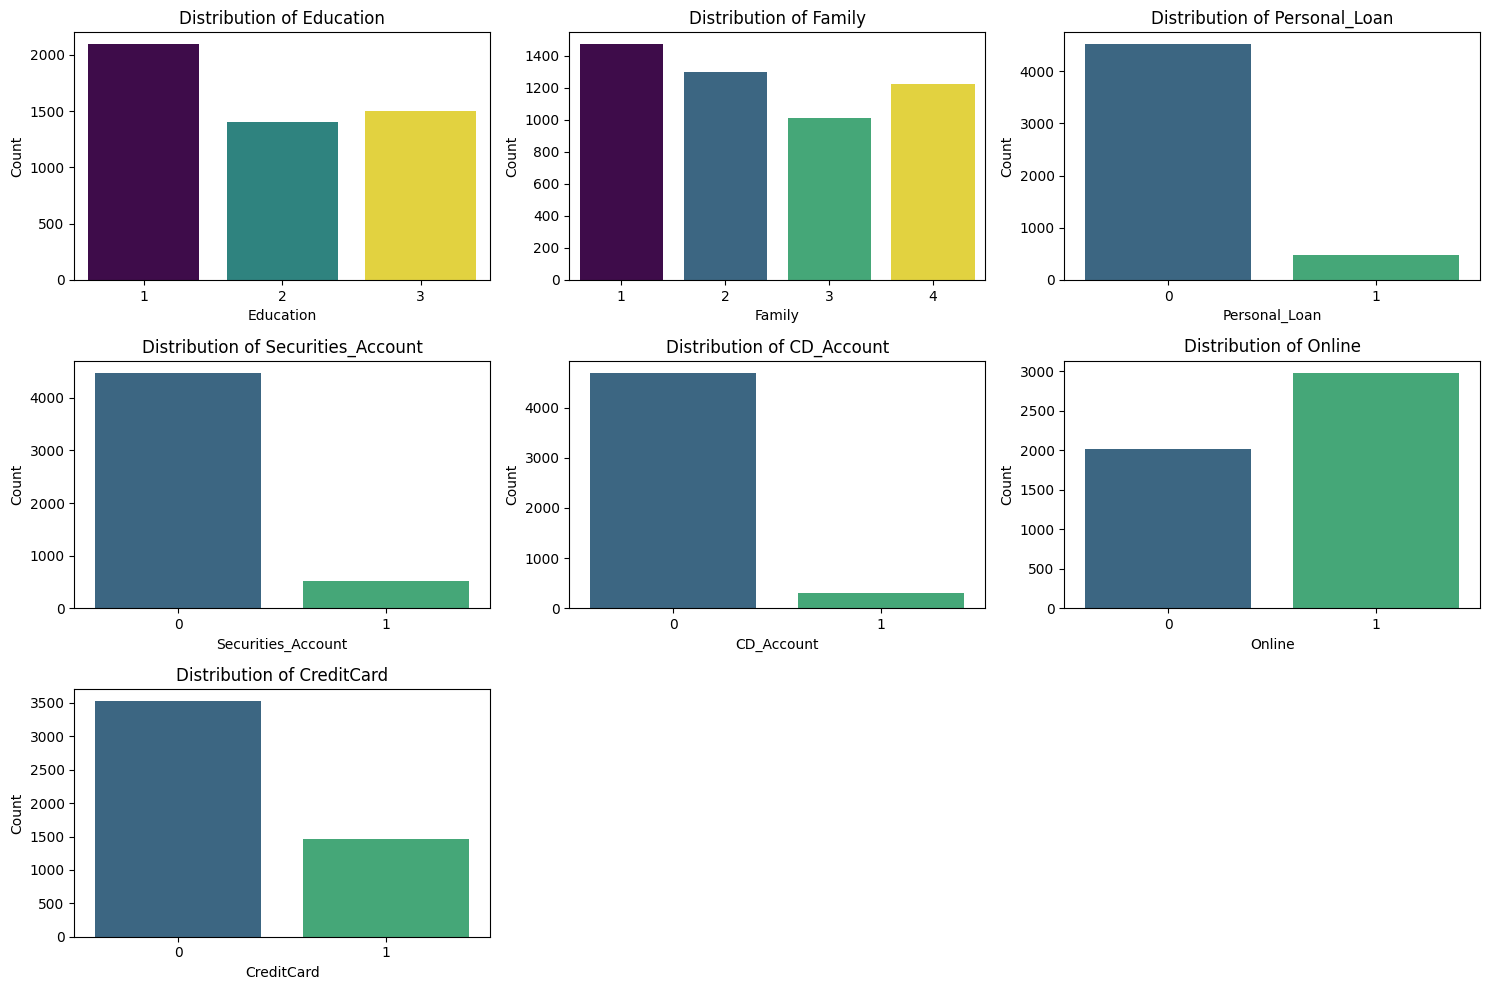

In [201]:
categorical_vars = [
    'Education', 'Family', 'Personal_Loan',
    'Securities_Account', 'CD_Account',
    'Online', 'CreditCard'
]

plt.figure(figsize=(15, 10))
for i, var in enumerate(categorical_vars):
    plt.subplot(3, 3, i + 1)  # Adjust subplot grid as needed

    # Updated countplot to avoid deprecation warning
    sns.countplot(x=var, data=customer_attributes_data,
                  hue=var, palette='viridis', legend=False)

    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Count')

    # Display value counts for numerical insight
    print(f"\n--- Value Counts for {var} ---")
    print(customer_attributes_data[var].value_counts())

plt.tight_layout()
plt.show()


**Observations from the Univariate Analysis of the Categorical Variables:**

### Securities_Account
The majority of customers do not hold a securities account with the bank.

### CD_Account
Very few customers have a certificate of deposit (CD) account.

Indicates low interest in long-term savings products or possibly limited awareness or accessibility.

### Online
A more balanced distribution is observed between users and non-users of internet banking.

This reflects a growing adoption of digital banking, though a significant portion still prefers traditional channels.

### CreditCard
Most customers do not use credit cards issued by other banks.

### Education
The distribution shows three levels:

1: Undergrad

2: Graduate

3: Advanced/Professional

Most customers fall into the Undergrad and Graduate categories.

Advanced/Professional education is less common, which may reflect the general population or targeting strategy of the bank.

This segmentation can help tailor financial products based on education level — e.g., advanced professionals may be more receptive to investment services.

### Family

Smaller families (1–2 members) are more prevalent.
Larger families (3–4) are less common, which may influence spending behavior and product needs.
Family size could correlate with mortgage demand, credit card usage, or savings behavior.

###Personal_Loan
Personal loan being our most important aspect of the campaign, the majority of customers did not accept the personal loan offer (value = 0).
Only a small fraction opted in (value = 1).
This suggests either:
Low interest in personal loans,
Ineffective campaign targeting,
Or stricter eligibility criteria.





**Univariate Analysis Of Numerical Columns**


--- Descriptive Statistics for Age ---
count    5000.000000
mean       45.338400
std        11.463166
min        23.000000
25%        35.000000
50%        45.000000
75%        55.000000
max        67.000000
Name: Age, dtype: float64

--- Descriptive Statistics for Experience ---
count    5000.000000
mean       20.104600
std        11.467954
min        -3.000000
25%        10.000000
50%        20.000000
75%        30.000000
max        43.000000
Name: Experience, dtype: float64

--- Descriptive Statistics for Income ---
count    5000.000000
mean       73.774200
std        46.033729
min         8.000000
25%        39.000000
50%        64.000000
75%        98.000000
max       224.000000
Name: Income, dtype: float64


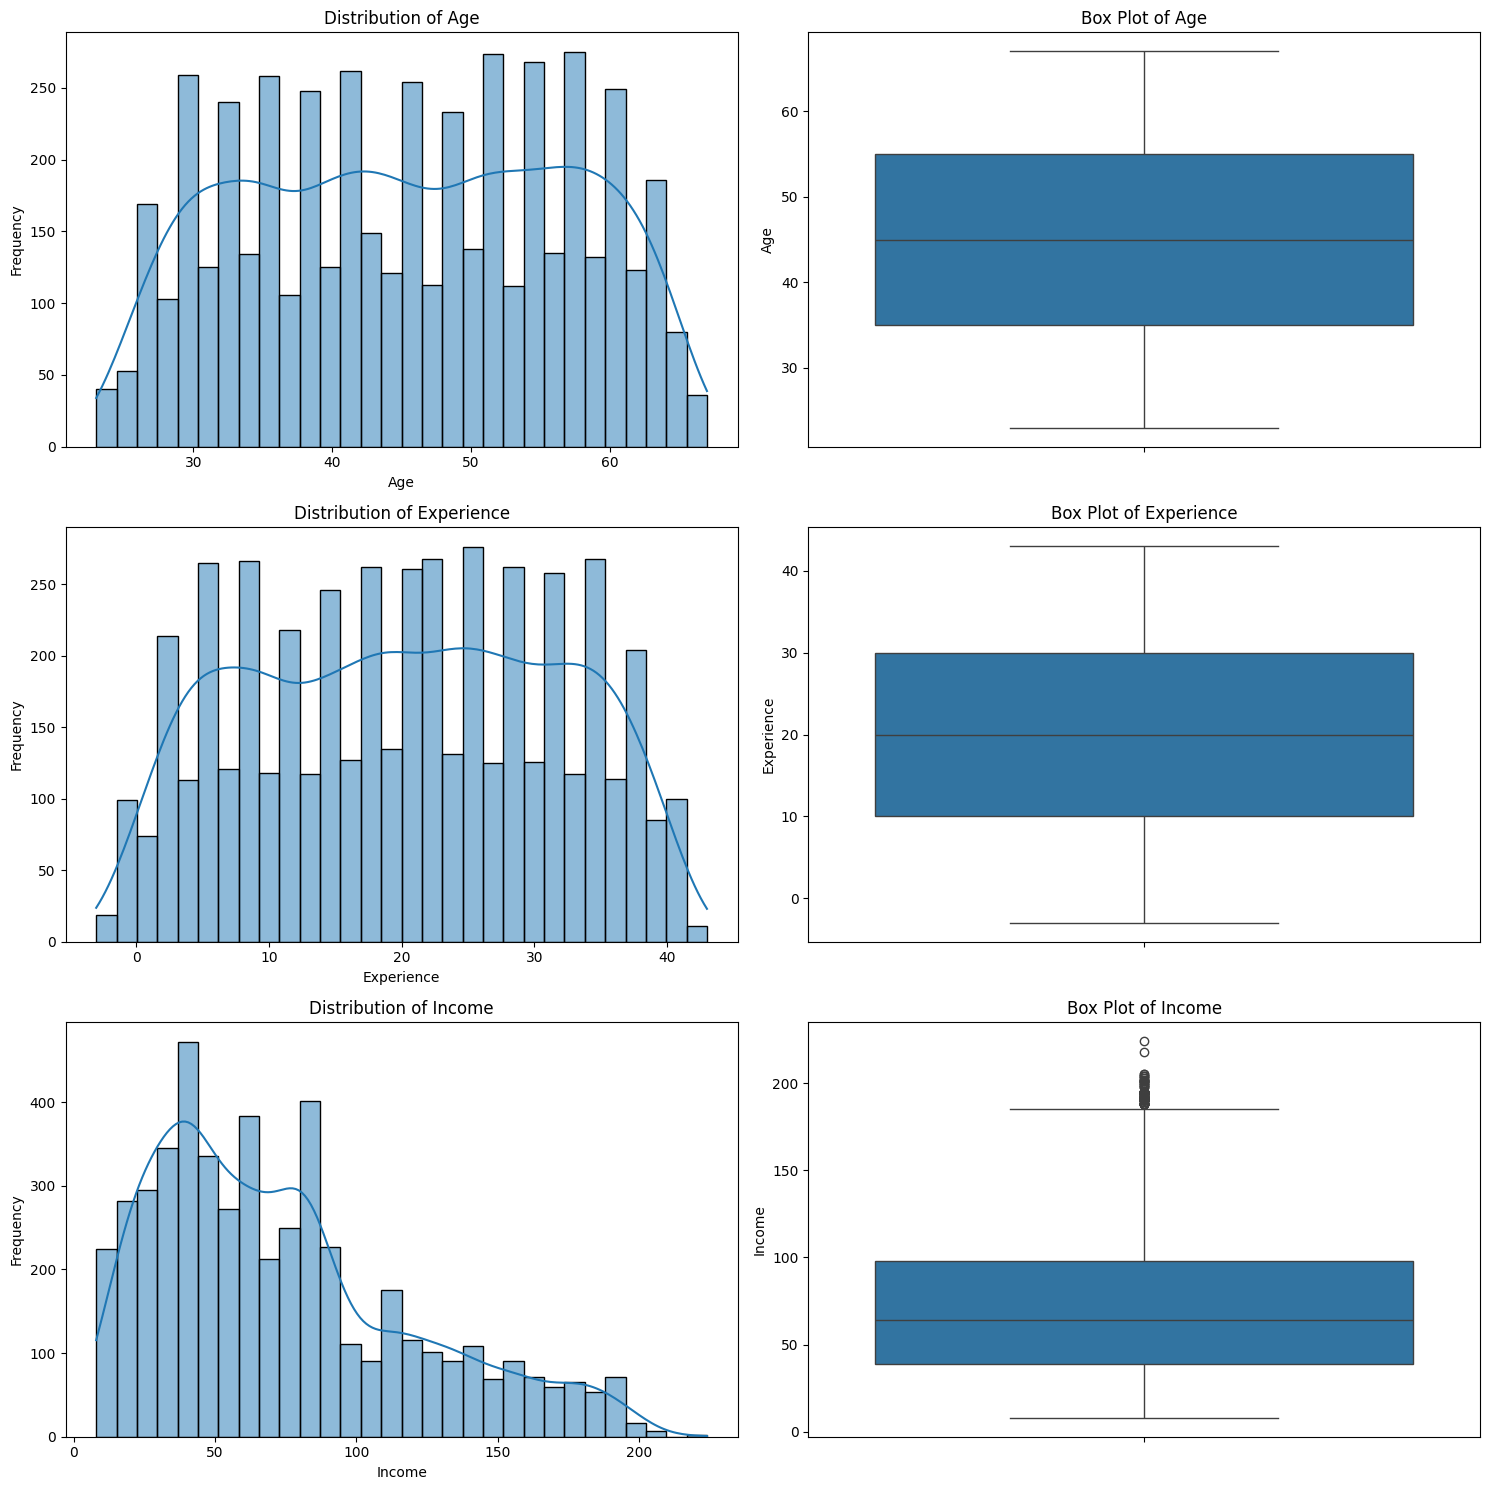

In [202]:
numerical_vars_to_plot = ['Age', 'Experience', 'Income']

plt.figure(figsize=(15, 15))
for i, var in enumerate(numerical_vars_to_plot):
    # Histogram for distribution
    plt.subplot(len(numerical_vars_to_plot), 2, 2*i + 1)
    sns.histplot(customer_attributes_data[var], kde=True, bins=30)
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')

    # Box plot for outliers and spread
    plt.subplot(len(numerical_vars_to_plot), 2, 2*i + 2)
    sns.boxplot(y=customer_attributes_data[var])
    plt.title(f'Box Plot of {var}')
    plt.ylabel(var)

    print(f"\n--- Descriptive Statistics for {var} ---")
    print(customer_attributes_data[var].describe())

plt.tight_layout()
plt.show()



### Age
Range: 23 to 67 years → dataset covers a broad adult age span.
Mean/Median: Average age ≈ 45, median = 45 → distribution is fairly symmetric.

Spread: Standard deviation ≈ 11.5 → most customers are between 34 and 56 years old (±1 SD).

The dataset is centered around middle-aged individuals, with relatively few very young or very old customers.

### Experience
Range: -3 to 43 years → negative minimum indicates data quality issue (experience cannot be negative).As we discovered during our sanity checks, there are some entries with negative experience.

Mean/Median: Average ≈ 20 years, median = 20 → distribution is balanced.

Spread: Standard deviation ≈ 11.5 → most customers have 9–31 years of experience.

Majority have moderate work experience, but negative values must be cleaned before further generating of the decision tree model.

###Income
Range: 8k to 224k (in thousand dollars per year).

Mean/Median: Average ≈ 74k, median = 64k → mean > median, indicating a right-skewed distribution (some very high earners).

Spread: Standard deviation ≈ 46k → wide variation in income levels.

Most customers earn between 39k and 98k (middle 50%), but a few high-income outliers push the mean upward.






**Factors Influencing Personal Loan Acceptance: A Bivariate Analysis with Personal Loan ---> Income, CCAvg, Education, Mortgage**

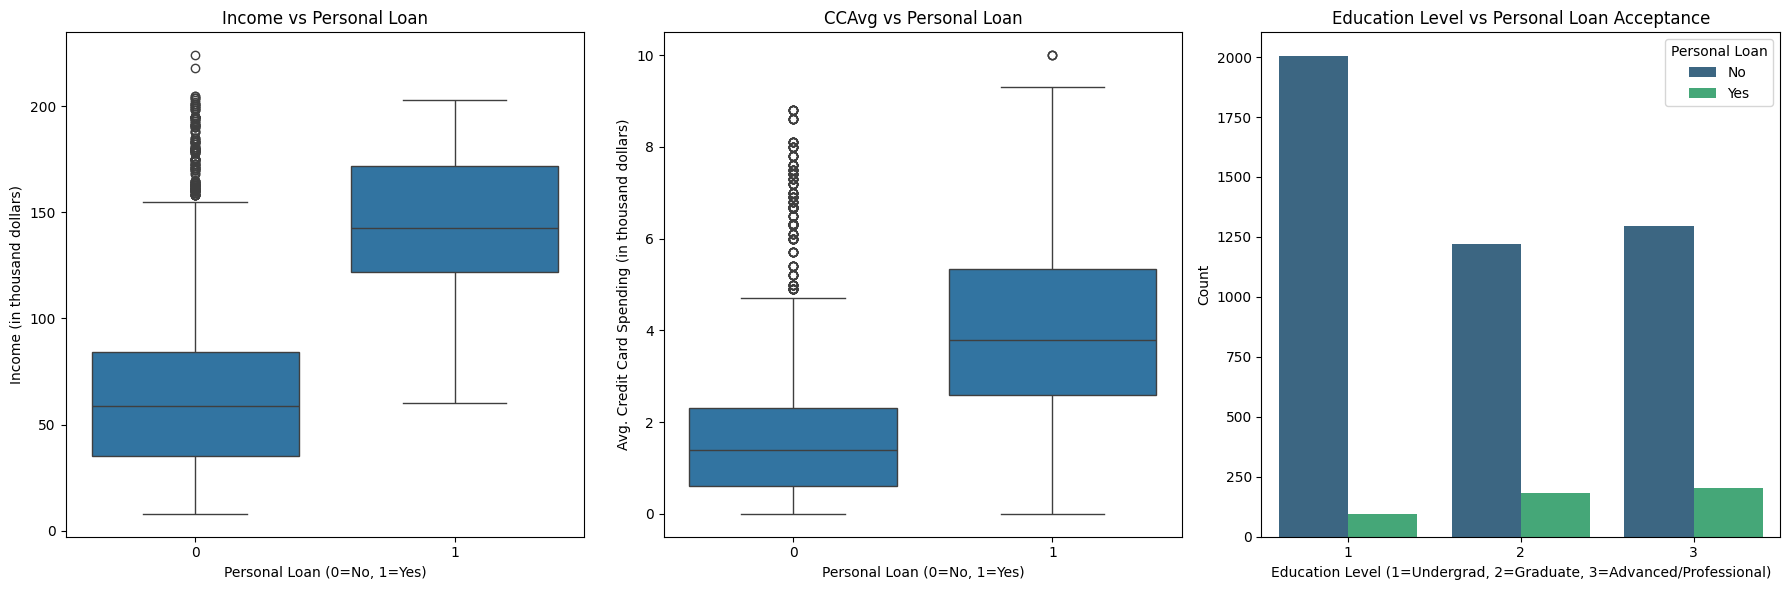

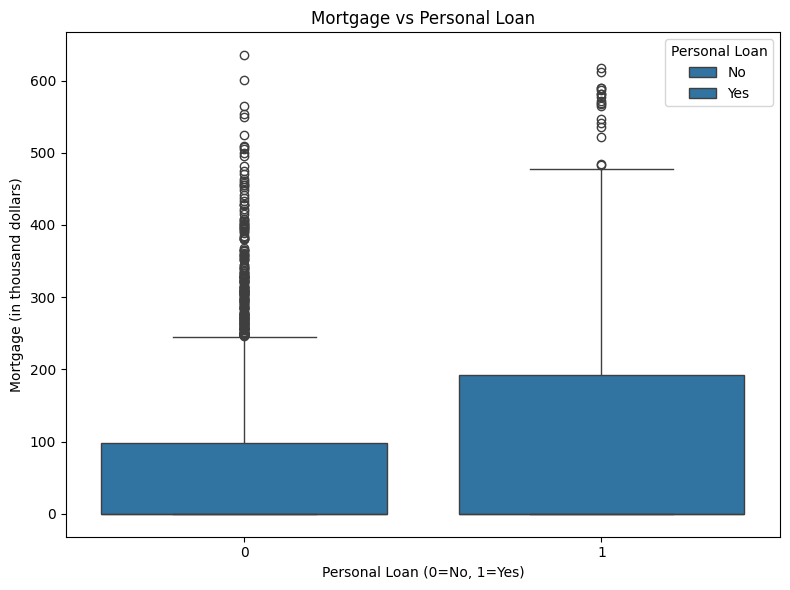

In [203]:
plt.figure(figsize=(18, 6))

# Income vs Personal_Loan
plt.subplot(1, 3, 1)
sns.boxplot(x='Personal_Loan', y='Income', data=customer_attributes_data)
plt.title('Income vs Personal Loan')
plt.xlabel('Personal Loan (0=No, 1=Yes)')
plt.ylabel('Income (in thousand dollars)')

# CCAvg vs Personal_Loan
plt.subplot(1, 3, 2)
sns.boxplot(x='Personal_Loan', y='CCAvg', data=customer_attributes_data)
plt.title('CCAvg vs Personal Loan')
plt.xlabel('Personal Loan (0=No, 1=Yes)')
plt.ylabel('Avg. Credit Card Spending (in thousand dollars)')

# Education vs Personal_Loan
plt.subplot(1, 3, 3)
sns.countplot(x='Education', hue='Personal_Loan', data=customer_attributes_data, palette='viridis')
plt.title('Education Level vs Personal Loan Acceptance')
plt.xlabel('Education Level (1=Undergrad, 2=Graduate, 3=Advanced/Professional)')
plt.ylabel('Count')
plt.legend(title='Personal Loan', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

# Mortgage vs Personal_Loan
plt.figure(figsize=(8, 6))
sns.boxplot(x='Personal_Loan', y='Mortgage', data=customer_attributes_data)
plt.title('Mortgage vs Personal Loan')
plt.xlabel('Personal Loan (0=No, 1=Yes)')
plt.ylabel('Mortgage (in thousand dollars)')
plt.legend(title='Personal Loan', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

### Income vs Personal Loan
Higher income correlates with loan acceptance: Individuals who accepted personal loans tend to have significantly higher incomes, with a median around $150K, compared to $60K for those who did not.

Outliers among non-acceptors: There are several high-income outliers among those who did not accept loans, suggesting income alone isn't the sole determinant.

Wider spread for non-acceptors: The income distribution for non-acceptors is more varied, indicating a broader range of financial backgrounds.

### Credit Card Spending (CCAvg) vs Personal Loan
Higher spending linked to loan acceptance: Median credit card spending is about $4K for loan acceptors versus $2K for non-acceptors.

Outliers among non-acceptors: Many individuals who did not accept loans still show high credit card spending, suggesting other factors may influence their decision.

Tighter distribution for acceptors: Spending among loan acceptors is more consistent, possibly reflecting a targeted financial behavior.

### Education Level vs Personal Loan Acceptance
Advanced education increases likelihood: Individuals with Graduate or Advanced/Professional degrees are more likely to accept personal loans than those with only undergraduate education.

Majority still decline loans: Across all education levels, most individuals do not accept personal loans, indicating education is influential but not decisive.

Sharp contrast between undergrad and advanced levels: The jump in loan acceptance from education level 1 to 3 is notable, suggesting a strong link between financial literacy or access and education.

###Mortgage vs Personal Loan
Higher mortgage amounts among loan acceptors: Individuals with personal loans tend to have larger mortgages, indicating greater financial obligations or access to credit.

Potential creditworthiness signal: Higher mortgage values may reflect better credit profiles, making these individuals more eligible or inclined to accept personal loans.

Presence of outliers: Both groups show outliers, but the distribution for loan acceptors skews higher overall.

**The distribution of mortgage attribute & noticeable patterns or outliers in the distribution**

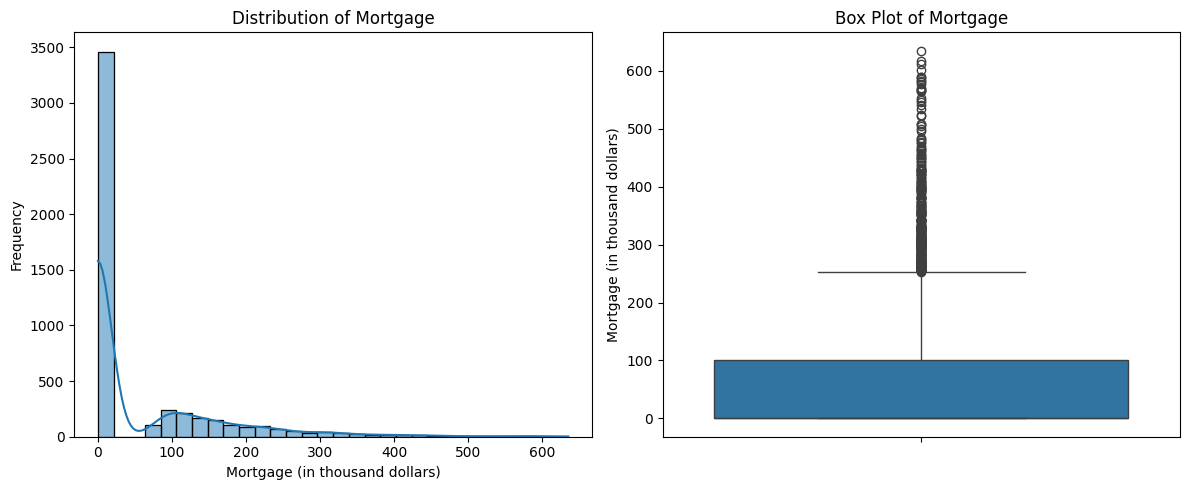


Descriptive Statistics for Mortgage:
 count    5000.000000
mean       56.498800
std       101.713802
min         0.000000
25%         0.000000
50%         0.000000
75%       101.000000
max       635.000000
Name: Mortgage, dtype: float64


In [204]:
plt.figure(figsize=(12, 5))

# Histogram for Mortgage distribution
plt.subplot(1, 2, 1)
sns.histplot(customer_attributes_data['Mortgage'], kde=True, bins=30)
plt.title('Distribution of Mortgage')
plt.xlabel('Mortgage (in thousand dollars)')
plt.ylabel('Frequency')

# Box plot for Mortgage to identify outliers
plt.subplot(1, 2, 2)
sns.boxplot(y=customer_attributes_data['Mortgage'])
plt.title('Box Plot of Mortgage')
plt.ylabel('Mortgage (in thousand dollars)')

plt.tight_layout()
plt.show()

# Describe the mortgage distribution numerically
print("\nDescriptive Statistics for Mortgage:\n", customer_attributes_data['Mortgage'].describe())

###Distribution of Mortgage (Histogram with Density Curve)
Right-skewed distribution: The histogram and density curve show that most individuals have low mortgage amounts, with frequency peaking near zero and tapering off as mortgage values increase.

Long tail of high values: A small number of individuals have significantly higher mortgage amounts, extending the distribution beyond 600 thousand dollars.

Concentration below 100K: The bulk of mortgage values are concentrated in the lower range, suggesting limited borrowing or conservative lending practices for most individuals.

###Box Plot of Mortgage
High number of outliers: The box plot reveals many outliers above the upper whisker, indicating that some individuals have exceptionally high mortgage amounts.

Compact interquartile range: Most mortgage values fall below 100 thousand dollars, with the middle 50% tightly grouped, reinforcing the skewed nature of the data.

Median below upper quartile: The median mortgage value is well below the upper quartile, further emphasizing the prevalence of lower mortgage amounts.

**Number Of Customers With Credit Cards**

In [205]:
credit_card_customers = customer_attributes_data[customer_attributes_data['CreditCard'] == 1].shape[0]
print(f"Number of customers with credit cards: {credit_card_customers}")

Number of customers with credit cards: 1470


**Analysing the attributes that have a strong correlation with the target attribute (personal loan)**

In [206]:
### Correlation check: If we compute correlation of ID with Personal_Loan, it will be near zero, confirming it has no meaningful relationship.
### We will be ignoring the ID column in correlation check.

In [207]:
selected_numerical_cols = ['Personal_Loan', 'Age', 'Income', 'CCAvg', 'Mortgage']
correlation_subset = customer_attributes_data[selected_numerical_cols].corr()

print("Correlation Matrix with Personal Loan and Selected Numerical Attributes:")
print(correlation_subset)

Correlation Matrix with Personal Loan and Selected Numerical Attributes:
               Personal_Loan       Age    Income     CCAvg  Mortgage
Personal_Loan       1.000000 -0.007726  0.502462  0.366889  0.142095
Age                -0.007726  1.000000 -0.055269 -0.052012 -0.012539
Income              0.502462 -0.055269  1.000000  0.645984  0.206806
CCAvg               0.366889 -0.052012  0.645984  1.000000  0.109905
Mortgage            0.142095 -0.012539  0.206806  0.109905  1.000000


### Observations Of The Correlation Between Personal Loan & Selected Numerical Attributes:

Income:
Strong positive correlation — higher income is strongly associated with accepting a personal loan.

CCAvg:
Moderate positive correlation — higher average credit card spending tends to align with loan acceptance.

Mortgage:
Weak positive correlation — larger mortgage values slightly increase likelihood of loan acceptance.

Age:
No meaningful correlation — age does not significantly influence loan acceptance.





### One-Hot Encode Categorical Variables and Calculate Correlations

Applying one-hot encoding to 'Education', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'Family' columns, then concatenate with other relevant columns. Calculating the correlation matrix for the new DataFrame and display correlations with the target variable 'Personal_Loan'.

In [208]:
# Make a copy of the dataframe to avoid modifying the original
df_encoded = customer_attributes_data.copy()

# List of columns to one-hot encode
categorical_cols_to_encode = ['Education', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'Family']

for col in categorical_cols_to_encode:
    # One-hot encode the column
    one_hot = pd.get_dummies(df_encoded[col], prefix=col, dtype=int)
    # Concatenate the one-hot encoded columns to the DataFrame
    df_encoded = pd.concat([df_encoded, one_hot], axis=1)
    # Drop the original categorical column
    df_encoded.drop(col, axis=1, inplace=True)

# Calculate the correlation matrix for the new DataFrame
correlation_matrix_encoded = df_encoded.corr(numeric_only=True)

# Get correlations with the target variable 'Personal_Loan' and sort them
personal_loan_correlations_encoded = correlation_matrix_encoded['Personal_Loan'].sort_values(ascending=False)

print("Correlations with 'Personal_Loan' after One-Hot Encoding:")
print(personal_loan_correlations_encoded)

Correlations with 'Personal_Loan' after One-Hot Encoding:
Personal_Loan           1.000000
Income                  0.502462
CCAvg                   0.366889
CD_Account_1            0.316355
Mortgage                0.142095
Education_3             0.090212
Education_2             0.071491
Family_3                0.060942
Family_4                0.026364
Securities_Account_1    0.021954
Online_1                0.006278
CreditCard_1            0.002802
CreditCard_0           -0.002802
ZIPCode                -0.002974
Online_0               -0.006278
Experience             -0.007413
Age                    -0.007726
Securities_Account_0   -0.021954
ID                     -0.024801
Family_2               -0.028532
Family_1               -0.051110
Education_1            -0.148894
CD_Account_0           -0.316355
Name: Personal_Loan, dtype: float64


### Positively Correlated Features with Personal_Loan

Income	0.502	Strong positive correlation — higher income is strongly associated with accepting a personal loan.

CCAvg	0.367	Moderate positive correlation — customers with higher credit card spending are more likely to accept loans.

CD_Account_1	0.316	Strong positive correlation — having a CD account is a strong indicator of loan acceptance.

Mortgage	0.142	Weak positive correlation — higher mortgage values slightly increase likelihood of loan acceptance.

Education_3	0.090	Slight positive correlation — customers with advanced/professional education are more likely to accept loans.

Education_2	0.071	Slight positive correlation — graduate-level education also shows mild association with loan acceptance.

Family_3	0.061	Slight positive correlation — larger family size may slightly increase loan uptake.

### Negatively Correlated Features with Personal_Loan

Education_1	-0.149	Moderate negative correlation — undergraduates are less likely to accept personal loans.

CD_Account_0	-0.316	Strong negative correlation — not having a CD account is associated with loan rejection.

Family_1	-0.051	Slight negative correlation — smaller families may be less inclined to accept loans.

Age / Experience	~-0.007	No meaningful correlation — age and experience do not significantly influence loan decisions.

Online / CreditCard / ZIPCode / ID	Near zero	These features show negligible correlation with loan acceptance.


### Customer's Interest In Purchasing A Loan Vary With Their Age & Education

Text(0, 0.5, 'Experience(years of professional experience)')

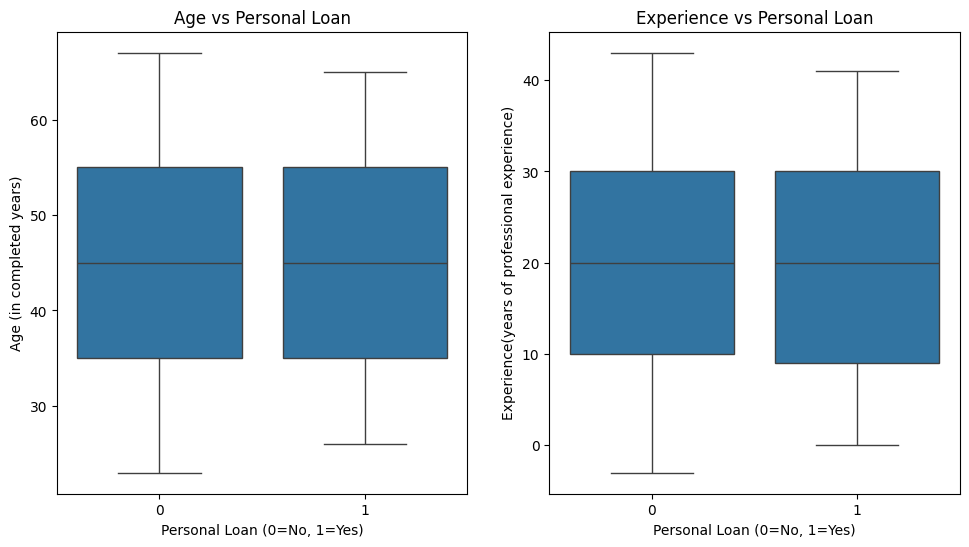

In [209]:
plt.figure(figsize=(18, 6))

# Age vs Personal_Loan
plt.subplot(1, 3, 1)
sns.boxplot(x='Personal_Loan', y='Age', data=customer_attributes_data)
plt.title('Age vs Personal Loan')
plt.xlabel('Personal Loan (0=No, 1=Yes)')
plt.ylabel('Age (in completed years)')

# CCAvg vs Personal_Loan
plt.subplot(1, 3, 2)
sns.boxplot(x='Personal_Loan', y='Experience', data=customer_attributes_data)
plt.title('Experience vs Personal Loan')
plt.xlabel('Personal Loan (0=No, 1=Yes)')
plt.ylabel('Experience(years of professional experience)')

### Box Plot 1: Numerical Variable (Range ~30 to 65)
Central tendency: The median value appears to be around the mid-40s, suggesting that most individuals fall within this range.

Outliers: There are a few data points outside the whiskers, suggesting the presence of outliers either below 30 or above 65.

### Box Plot 2: Experience (Years of Professional Experience)
Central tendency: The median experience is around 15–20 years, indicating that most individuals have moderate professional tenure.

Outliers: Several individuals have very low or very high experience values (e.g., near 0 or above 35), indicating a diverse range of professional backgrounds.



## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

 **Analysing Presence Of Missing Value & Treating The Same**

Summarizing statistics for each column. Checking If counts differ across columns, indicating\ missing values.

In [210]:
customer_attributes_data.describe(include='all')

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93169.257000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,1759.455086,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,90005.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


### Observations

The dataset has 5000 rows, and the count for every column is 5000, it means every row has an entry for that column.

Therefore, there are no missing values in the dataset.

### Checking For Nulls In Each Columns

In [211]:
print("Checking for nulls in columns:")
numerical_cols = customer_attributes_data.select_dtypes(include=np.number).columns
for col in numerical_cols:
    missing_count = customer_attributes_data[col].isnull().sum()
    if missing_count > 0:
        print(f"  {col}: {missing_count} missing values")
    else:
        print(f"  {col}: No missing values")


Checking for nulls in columns:
  ID: No missing values
  Age: No missing values
  Experience: No missing values
  Income: No missing values
  ZIPCode: No missing values
  Family: No missing values
  CCAvg: No missing values
  Education: No missing values
  Mortgage: No missing values
  Personal_Loan: No missing values
  Securities_Account: No missing values
  CD_Account: No missing values
  Online: No missing values
  CreditCard: No missing values


### Observations

Indicates these are no nulls in the 5000 entries.

Additionally our unique checks in the data sanity analysis shows thats all the columns has expected values in valid ranges, excluding experience.



**Feature Engineering**

**Feature Engineering 1 - As a step towards feature engineering, introducing  Spending_to_Income_Ratio = CCAvg / Income**

Definition: This compares average monthly credit card spending (CCAvg) to annual income.

Purpose: It measures financial behavior and spending intensity relative to income.

Interpretation:

Higher ratio → customer spends a large portion of their income on credit cards, possibly indicating higher debt or reliance on credit.

Lower ratio → customer spends conservatively relative to income, suggesting more financial stability.

In [212]:
# Calculate Spending_to_Income_Ratio
customer_attributes_data['Spending_to_Income_Ratio'] = customer_attributes_data['CCAvg'] / customer_attributes_data['Income']

print("New columns 'Income_per_Family' and 'Spending_to_Income_Ratio' created.")
print(customer_attributes_data[['Income', 'Family','CCAvg', 'Spending_to_Income_Ratio']].head())

New columns 'Income_per_Family' and 'Spending_to_Income_Ratio' created.
   Income  Family  CCAvg  Spending_to_Income_Ratio
0      49       4    1.6                  0.032653
1      34       3    1.5                  0.044118
2      11       1    1.0                  0.090909
3     100       1    2.7                  0.027000
4      45       4    1.0                  0.022222


### Observations

Spending_to_Income_Ratio tells you how much of income is consumed by credit card spending.

**Feature Engineering 2 – As a step towards feature engineering, introducing Region_From_ZIP = Mapping ZIPCode → State**

Definition: This converts each customer’s ZIP code into a broader geographic category such as state (e.g., Massachusetts, California).

Purpose: It captures the influence of location on customer behavior and loan acceptance. Regional differences often reflect socioeconomic conditions, access to financial services, and lifestyle patterns.

Unmapped or missing ZIPs → can be flagged as “Unknown,” allowing the model to learn whether missing location data itself carries predictive value.

In [213]:
# Initialize the Nominatim search engine for US ZIP codes
nomi = pgeocode.Nominatim('us')

# Define a function to get the state from a ZIP code
def get_state_from_zip(zip_code):
    # Ensure ZIP is a 5-digit string
    zip_str = str(zip_code).zfill(5)
    result = nomi.query_postal_code(zip_str)

    # pgeocode returns a pandas Series; check for valid state_name
    if result is not None and not pd.isna(result.state_name):
        return result.state_name
    return None  # Return None if no state is found

# Apply the function to the 'ZIPCode' column to create the new 'State' column
customer_attributes_data['State'] = customer_attributes_data['ZIPCode'].apply(get_state_from_zip)

print("New 'State' column created based on ZIP codes.")
print(customer_attributes_data[['ZIPCode', 'State']].head())

# Check for any ZIP codes that could not be mapped to a state
unknown_states_count = customer_attributes_data['State'].isnull().sum()
if unknown_states_count > 0:
    print(f"\nWarning: {unknown_states_count} ZIP codes could not be mapped to a state (resulting in None values).")
    print("You might want to investigate these unmapped ZIP codes or handle them appropriately.")


New 'State' column created based on ZIP codes.
   ZIPCode       State
0    91107  California
1    90089  California
2    94720  California
3    94112  California
4    91330  California

You might want to investigate these unmapped ZIP codes or handle them appropriately.


In [214]:
# Filter the DataFrame to find rows where 'State' is None (unmapped ZIP codes)
unmapped_zip_data = customer_attributes_data[customer_attributes_data['State'].isnull()]

# Get the unique unmapped ZIP codes
unique_unmapped_zipcodes = unmapped_zip_data['ZIPCode'].unique()

print(f"Number of unique unmapped ZIP codes: {len(unique_unmapped_zipcodes)}")
print("Unique unmapped ZIP codes:")
print(unique_unmapped_zipcodes)

# Optionally, display a sample of the rows with unmapped ZIP codes
print("\nSample of rows with unmapped ZIP codes:")
display(unmapped_zip_data.head())

Number of unique unmapped ZIP codes: 5
Unique unmapped ZIP codes:
[92717 93077 92634 96651 92709]

Sample of rows with unmapped ZIP codes:


,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Spending_to_Income_Ratio,State
106,107,43,17,69,92717,4,2.9,1,0,0,0,0,1,1,0.042029,None
172,173,38,13,171,92717,2,7.8,1,0,0,0,0,1,0,0.045614,None
184,185,52,26,63,92717,2,1.5,2,0,0,1,0,1,0,0.023810,None
321,322,44,20,101,92717,3,4.4,2,82,1,0,0,0,0,0.043564,None
366,367,50,24,35,92717,1,0.3,3,0,0,0,0,1,0,0.008571,None


In [270]:
# Fill None values in the 'State' column with 'Unknown'
customer_attributes_data.fillna({'State': 'Unknown'}, inplace=True)

print("Unmapped ZIP codes (None values in 'State') have been replaced with 'Unknown'.")
print(customer_attributes_data[['ZIPCode', 'State']].head())

# Verify that there are no more nulls in the 'State' column
print(f"\nNumber of null values in 'State' column after treatment: {customer_attributes_data['State'].isnull().sum()}")

Unmapped ZIP codes (None values in 'State') have been replaced with 'Unknown'.
   ZIPCode       State
0    91107  California
1    90089  California
2    94720  California
3    94112  California
4    91330  California

Number of null values in 'State' column after treatment: 0


### Observations

There are totally 41 rows without unmapped zipcodes

The unique of these unmapped zipcodes are - [92717 93077 92634 96651 92709]

We are flagging the unmapped zipcodes as 'unknown'

**Outliers Treatments**


Outlier Treatment Decision – Not Applied

Definition: Outliers are extreme values in features such as Income or CCAvg that deviate significantly from the majority of observations.

Reasoning: In this dataset, high values of Income and CCAvg are not necessarily errors — they may represent legitimate customers with unusually high earnings or spending patterns. These customers are often the ones most likely to accept personal loans, so removing or capping their values could eliminate important predictive signals.

Interpretation:

High Income → may directly increase the likelihood of loan acceptance, since these customers have greater borrowing capacity.

High CCAvg (credit card spending) → may indicate reliance on credit or higher financial activity, which can also correlate with loan acceptance.

Treating these values as outliers would risk discarding meaningful information that the decision tree model can use to split customers into relevant groups.

Conclusion: Outlier treatment is not applied in this case. Instead, extreme values are retained to preserve their potential predictive power in the model.



### **Data Preparation for Modeling**

### Viewing The Shape Of The Current Data After All The EDA & Missing Values Treatment

In [216]:
# Create a copy of the DataFrame to prepare for model building
data_for_model = customer_attributes_data.copy()

# Drop 'ID' and 'Experience' columns as they are not needed for modeling
data_for_model.drop(['ID', 'Experience'], axis=1, inplace=True)

print("DataFrame prepared for model building with 'ID' and 'Experience' columns dropped:")
print(data_for_model.head())
print(f"\nShape of the DataFrame for model building: {data_for_model.shape}")

DataFrame prepared for model building with 'ID' and 'Experience' columns dropped:
   Age  Income  ZIPCode  Family  CCAvg  Education  Mortgage  Personal_Loan  \
0   25      49    91107       4    1.6          1         0              0   
1   45      34    90089       3    1.5          1         0              0   
2   39      11    94720       1    1.0          1         0              0   
3   35     100    94112       1    2.7          2         0              0   
4   35      45    91330       4    1.0          2         0              0   

   Securities_Account  CD_Account  Online  CreditCard  \
0                   1           0       0           0   
1                   1           0       0           0   
2                   0           0       0           0   
3                   0           0       0           0   
4                   0           0       0           1   

   Spending_to_Income_Ratio       State  
0                  0.032653  California  
1                  0.0

### Dropping Additional Added Columns While Performing ZipCode Mapping

In [217]:
# Drop the unwanted columns if they exist
columns_to_drop = [
    'latitude_x', 'longitude_x', 'community_name_x',
    'latitude_y', 'longitude_y', 'community_name_y'
]

# Check if columns exist before dropping to avoid errors
existing_columns_to_drop = [col for col in columns_to_drop if col in data_for_model.columns]

if existing_columns_to_drop:
    data_for_model.drop(existing_columns_to_drop, axis=1, inplace=True)
    print(f"Dropped columns: {existing_columns_to_drop}")
else:
    print("No extra latitude, longitude, or community_name columns found to drop.")

print("\nDataFrame after removing extra columns (first 5 rows):")
print(data_for_model.head())
print(f"\nShape of the DataFrame: {data_for_model.shape}")

No extra latitude, longitude, or community_name columns found to drop.

DataFrame after removing extra columns (first 5 rows):
   Age  Income  ZIPCode  Family  CCAvg  Education  Mortgage  Personal_Loan  \
0   25      49    91107       4    1.6          1         0              0   
1   45      34    90089       3    1.5          1         0              0   
2   39      11    94720       1    1.0          1         0              0   
3   35     100    94112       1    2.7          2         0              0   
4   35      45    91330       4    1.0          2         0              0   

   Securities_Account  CD_Account  Online  CreditCard  \
0                   1           0       0           0   
1                   1           0       0           0   
2                   0           0       0           0   
3                   0           0       0           0   
4                   0           0       0           1   

   Spending_to_Income_Ratio       State  
0                  

### Defining the Dependent & Independent Variables

In [271]:
# Define the target variable (dependent variable)
y = data_for_model['Personal_Loan']

# Define the explanatory variables (independent variables)
# Drop 'Personal_Loan' as it's the target, and 'ZIPCode' as it's high cardinality and 'State' provides geographical info
X = data_for_model.drop(['Personal_Loan', 'ZIPCode'], axis=1)

# Identify categorical columns for one-hot encoding
categorical_cols = [
    'Family',
    'Education',
    'Securities_Account',
    'CD_Account',
    'Online',
    'CreditCard',
    'State' # Include the newly created 'State' column
]

# Apply one-hot encoding to categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)

print("Shape of explanatory variables (X):", X.shape)
print("Shape of response variable (y):", y.shape)
print("\nFirst 5 rows of explanatory variables (X) after encoding:")
print(X.head())

Shape of explanatory variables (X): (5000, 15)
Shape of response variable (y): (5000,)

First 5 rows of explanatory variables (X) after encoding:
   Age  Income  CCAvg  Mortgage  Spending_to_Income_Ratio  Family_2  Family_3  \
0   25      49    1.6         0                  0.032653         0         0   
1   45      34    1.5         0                  0.044118         0         1   
2   39      11    1.0         0                  0.090909         0         0   
3   35     100    2.7         0                  0.027000         0         0   
4   35      45    1.0         0                  0.022222         0         0   

   Family_4  Education_2  Education_3  Securities_Account_1  CD_Account_1  \
0         1            0            0                     1             0   
1         0            0            0                     1             0   
2         0            0            0                     0             0   
3         0            1            0                     0

Splitting the Training & Test Data With 80:20 Ratio

In [219]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (4000, 15)
Shape of y_train: (4000,)
Shape of X_test: (1000, 15)
Shape of y_test: (1000,)


## Model Building

### **Default Model Generation**

In [272]:
# Initialize the Decision Tree Classifier
dtree = DecisionTreeClassifier(random_state=42)

# Fit the model to the training data
dtree.fit(X_train, y_train)

# Make predictions on the test data
y_pred_dtree = dtree.predict(X_test)

print("Decision Tree Model built successfully.")

Decision Tree Model built successfully.


### Model Evaluation Criterion

This function below computes and displays a model’s accuracy, recall, F1-score, and precision for evaluation.

In [246]:
def get_train_test_scores(model, model_name, X_train, y_train, X_test, y_test):
    """
    Calculates and prints accuracy, recall, f1-score, and precision
    for both training and test datasets, and returns them as dictionaries.
    """
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training scores
    train_metrics = {
        'Accuracy': accuracy_score(y_train, y_train_pred),
        'Recall': recall_score(y_train, y_train_pred),
        'Precision': precision_score(y_train, y_train_pred),
        'F1 Score': f1_score(y_train, y_train_pred)
    }
    print(f"--- Training Metrics for {model_name} ---")
    for metric, value in train_metrics.items():
        print(f"{metric}: {value:.4f}")
    print("\n")

    # Test scores
    test_metrics = {
        'Accuracy': accuracy_score(y_test, y_test_pred),
        'Recall': recall_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred),
        'F1 Score': f1_score(y_test, y_test_pred)
    }
    print(f"--- Test Metrics for {model_name} ---")
    for metric, value in test_metrics.items():
        print(f"{metric}: {value:.4f}")
    print("\n")

    return train_metrics, test_metrics


This function visualizes a model’s performance by plotting a labeled confusion matrix heatmap.

In [247]:
def plot_confusion_matrix(model_name, y_true, y_pred):
    """
    Generates and plots a confusion matrix.

    Args:
        model_name (str): Name of the model for display purposes.
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.
    """
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Example usage for the Decision Tree model you just built:
#plot_confusion_matrix("Decision Tree (Default)", y_test, y_pred_dtree)

Function below visualizes a given tree

In [248]:

def plot_decision_tree(model, feature_names, class_names, title="Decision Tree Visualization"):
    """
    Generates and displays a visualization of a decision tree model.

    Args:
        model (DecisionTreeClassifier): The trained Decision Tree model.
        feature_names (list): List of feature names for the X variables.
        class_names (list): List of class names for the target variable.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(25, 15))
    tree.plot_tree(model,
                   feature_names=feature_names,
                   class_names=class_names,
                   filled=True,
                   rounded=True,
                   fontsize=10)
    plt.title(title)
    plt.show()

# Example usage:
# Assuming X.columns are your feature names and y has 0 and 1 as classes
# feature_names = X.columns.tolist()
# class_names = ['No Loan', 'Loan'] # Adjust based on your target variable's meaning
# plot_decision_tree(dtree, feature_names, class_names, title="Default Decision Tree")

In [249]:

def print_decision_tree_text(model, feature_names, class_names=None, show_weights=True, decimals=4):
    """
    Generates and prints the textual representation of a decision tree model.

    Args:
        model (DecisionTreeClassifier): The trained Decision Tree model.
        feature_names (list): List of feature names for the X variables.
        class_names (list, optional): List of class names for the target variable.
                                     Defaults to None.
        show_weights (bool): Whether or not to show the weights associated with the model.
                              Defaults to True.
        decimals (int): Number of decimal places for numeric values. Defaults to 4.
    """
    text_representation = tree.export_text(
        model,
        feature_names=feature_names,
        class_names=class_names,
        show_weights=show_weights,
        decimals=decimals
    )
    print(text_representation)

# Example usage with your default decision tree:
# feature_names = X_train.columns.tolist()
# class_names = ['No Loan', 'Loan']
# print_decision_tree_text(dtree, feature_names, class_names=class_names)



**Default model's  accuracy, recall, F1-score,precision, confusion matrix and visualization**





Default Model's scores

In [273]:

# Call the function to evaluate both train and test performance
get_train_test_scores(
    model=dtree,
    model_name="Decision Tree (Default)",
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

--- Training Metrics for Decision Tree (Default) ---
Accuracy: 1.0000
Recall: 1.0000
Precision: 1.0000
F1 Score: 1.0000


--- Test Metrics for Decision Tree (Default) ---
Accuracy: 0.9860
Recall: 0.9792
Precision: 0.8868
F1 Score: 0.9307




({'Accuracy': 1.0, 'Recall': 1.0, 'Precision': 1.0, 'F1 Score': 1.0},
 {'Accuracy': 0.986,
  'Recall': 0.9791666666666666,
  'Precision': 0.8867924528301887,
  'F1 Score': 0.9306930693069307})

### Default Model's Confusion Matrix



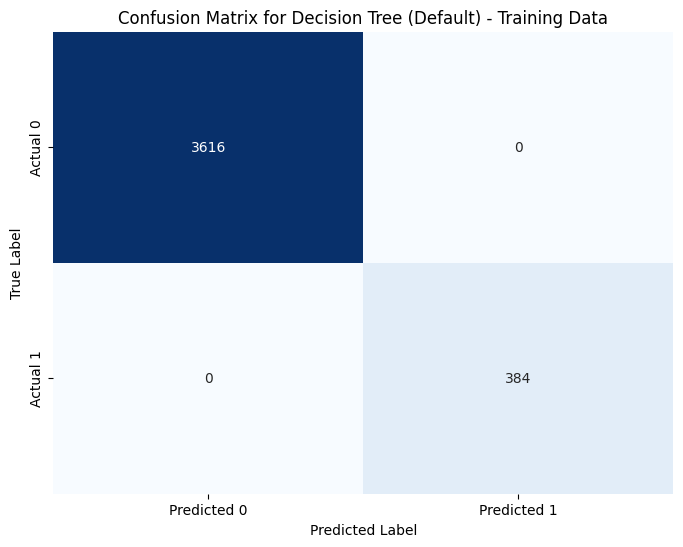

In [251]:
# Make predictions on the training data
y_train_pred = dtree.predict(X_train)

# Call the plot_confusion_matrix function for the training data
plot_confusion_matrix("Decision Tree (Default) - Training Data", y_train, y_train_pred)

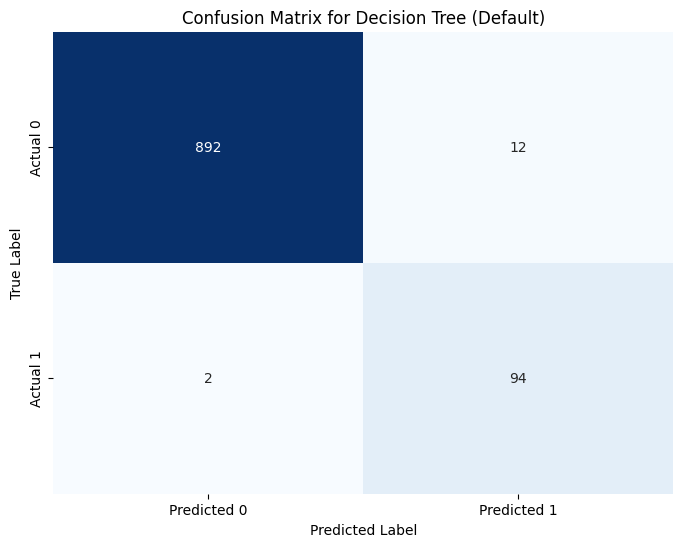

In [252]:
plot_confusion_matrix("Decision Tree (Default)", y_test, y_pred_dtree)

**Confusion Matrix Interpretation (Training Data)**

True Negatives (TN = 3616) → Model correctly predicted class 0 (e.g., loan rejection).

False Positives (FP = 0) → Model did not incorrectly predict any class 1 when it was actually 0.

False Negatives (FN = 0) → Model did not miss any actual positives (e.g., loan acceptances).

True Positives (TP = 384) → Model correctly predicted class 1 (loan acceptance).

**Performance Metrics Interpretation (Training Data)**
Accuracy: 1.0000 → 100% of predictions are correct.

Recall: 1.0000 → 100% of actual positives were correctly identified.

Precision: 1.0000 → 100% of predicted positives were truly positive.

F1 Score: 1.0000 → Perfect balance between precision and recall.


**Confusion Matrix Interpretation (Testing Data)**
True Negatives (TN = 892) → Model correctly predicted class 0 (e.g., loan rejection).

False Positives (FP = 12) → Model incorrectly predicted class 1 when it was actually 0.

False Negatives (FN = 2) → Model missed 2 actual positives (e.g., loan acceptances).

True Positives (TP = 94) → Model correctly predicted class 1 (loan acceptance).


**Performance Metrics Interpretation (Test Data)**
Accuracy: 0.9860 → 98.6% of predictions are correct.

Recall: 0.9792 → 97.9% of actual positives were correctly identified.

Precision: 0.8868 → 88.7% of predicted positives were truly positive.

F1 Score: 0.9307 → Strong balance between precision and recall.

### `Default Model's Visualization`

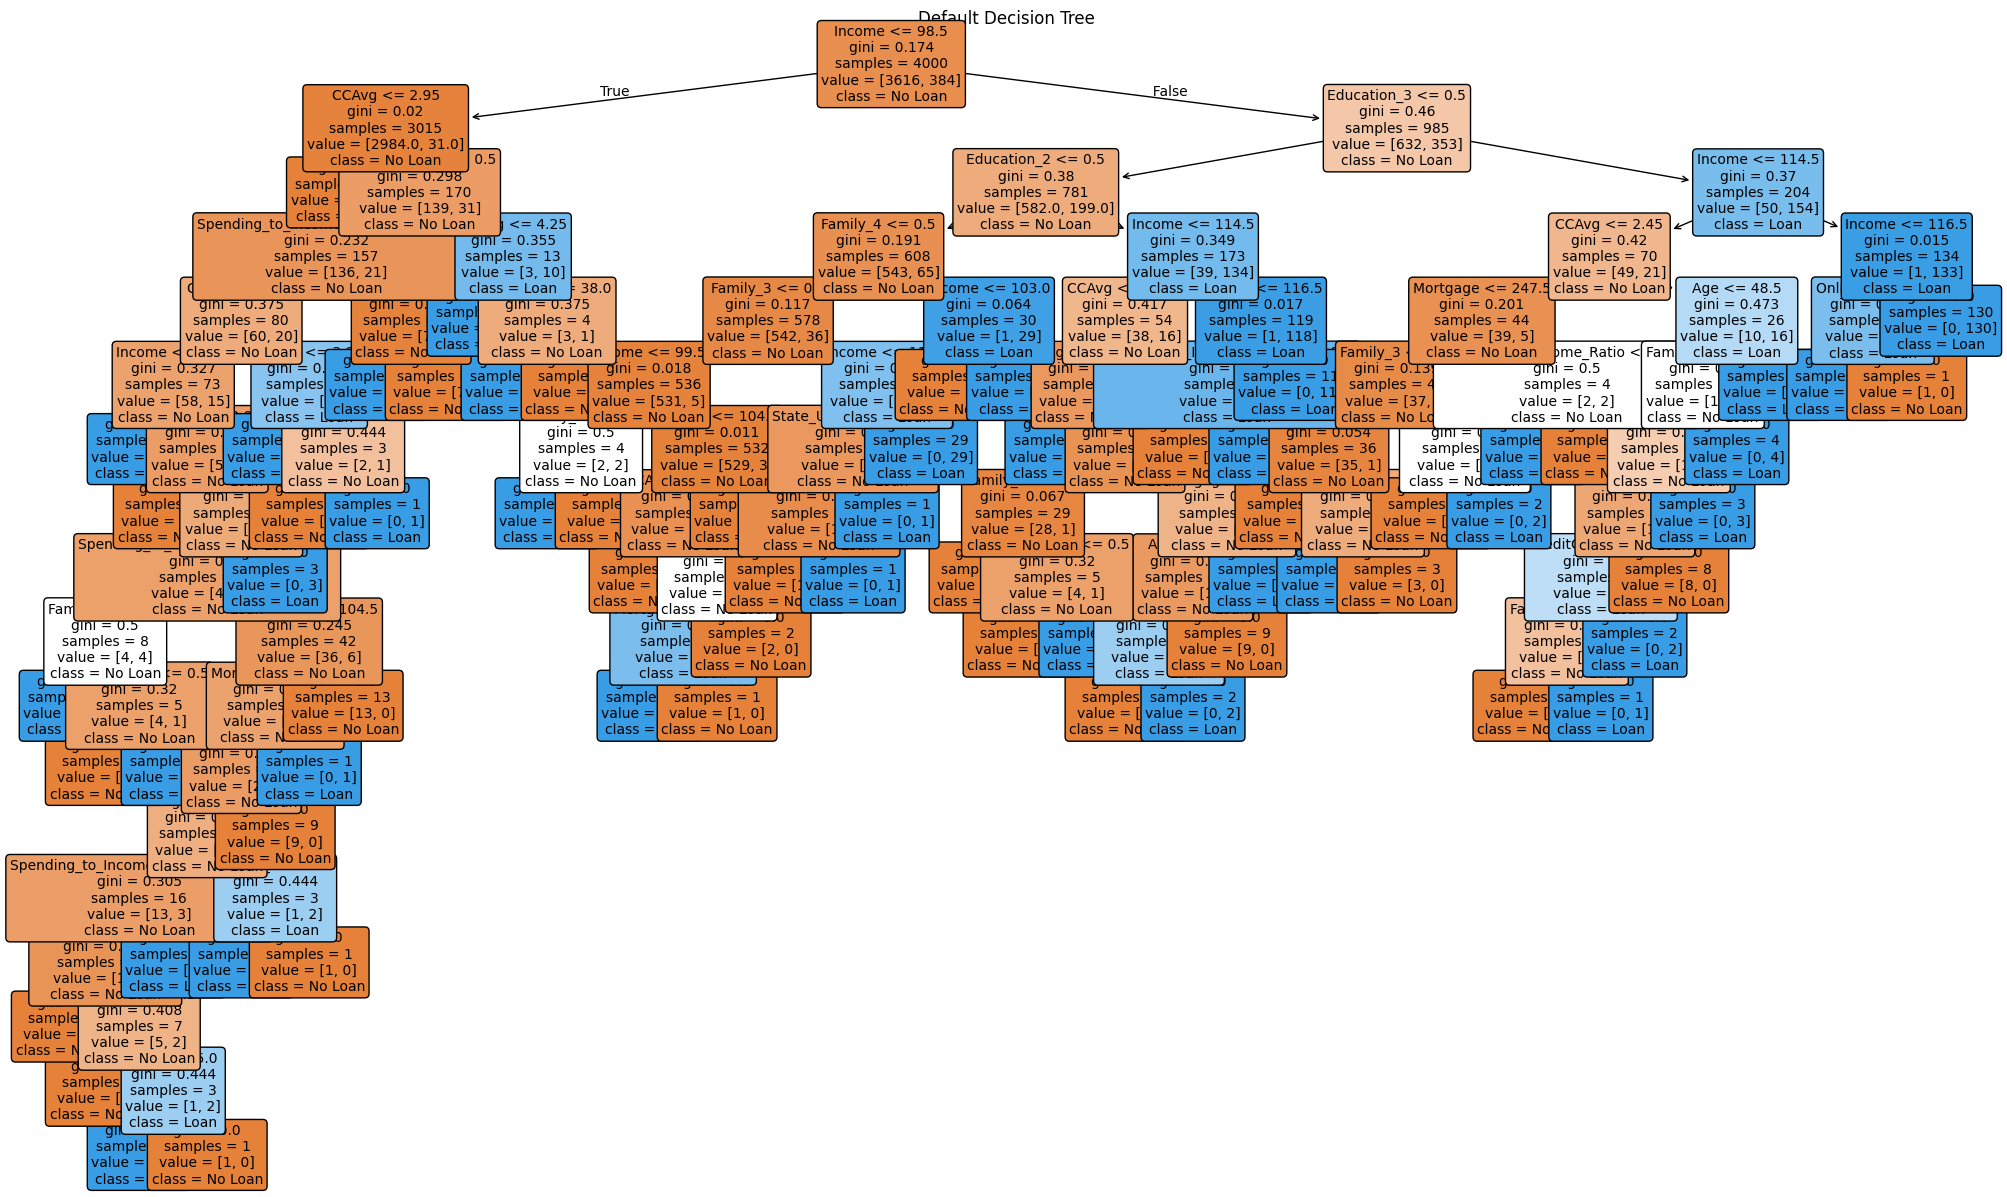

In [253]:
# Get feature names from the training data
feature_names = X_train.columns.tolist()

# Define class names for the target variable
class_names = ['No Loan', 'Loan'] # 0 for No, 1 for Yes

# Visualize the default decision tree
plot_decision_tree(dtree, feature_names, class_names, title="Default Decision Tree")

In [254]:
feature_names = X_train.columns.tolist()
class_names = ['No Loan', 'Loan']
print_decision_tree_text(dtree, feature_names, class_names=class_names)

|--- Income <= 98.5000
|   |--- CCAvg <= 2.9500
|   |   |--- weights: [2845.0000, 0.0000] class: No Loan
|   |--- CCAvg >  2.9500
|   |   |--- CD_Account_1 <= 0.5000
|   |   |   |--- Spending_to_Income_Ratio <= 0.0470
|   |   |   |   |--- CCAvg <= 3.8500
|   |   |   |   |   |--- Income <= 66.5000
|   |   |   |   |   |   |--- weights: [0.0000, 2.0000] class: Loan
|   |   |   |   |   |--- Income >  66.5000
|   |   |   |   |   |   |--- CCAvg <= 3.0500
|   |   |   |   |   |   |   |--- weights: [18.0000, 0.0000] class: No Loan
|   |   |   |   |   |   |--- CCAvg >  3.0500
|   |   |   |   |   |   |   |--- Family_3 <= 0.5000
|   |   |   |   |   |   |   |   |--- Spending_to_Income_Ratio <= 0.0391
|   |   |   |   |   |   |   |   |   |--- Family_2 <= 0.5000
|   |   |   |   |   |   |   |   |   |   |--- weights: [0.0000, 3.0000] class: Loan
|   |   |   |   |   |   |   |   |   |--- Family_2 >  0.5000
|   |   |   |   |   |   |   |   |   |   |--- Education_2 <= 0.5000
|   |   |   |   |   |   |   |   |

### Model Building

### **Decision Tree (Pre-pruning)**

###Generating pre-Pruned Model

In [255]:
# Expanded parameter grid for pre-pruning
param_grid = {
    'max_depth': np.arange(2, 15),
    'min_samples_leaf': np.arange(5, 50, 5),
    'min_samples_split': [10, 20, 30],        # control minimum split size
    'max_features': [None, 'sqrt', 'log2'],   # restrict features at each split
    'class_weight': [None, 'balanced']        # handle class imbalance
}

# Initialize the Decision Tree Classifier
dtree_pruning = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=dtree_pruning,
    param_grid=param_grid,
    cv=5,              # 5-fold cross-validation
    scoring='f1',      # Optimize for F1-score
    n_jobs=-1,         # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score: ", grid_search.best_score_)

# Train a new Decision Tree model with the best parameters
dtree_prepruned = DecisionTreeClassifier(
    **grid_search.best_params_,
    random_state=42
)
dtree_prepruned.fit(X_train, y_train)

# Make predictions with the pre-pruned model
y_pred_prepruned = dtree_prepruned.predict(X_test)

print("\nPre-pruned Decision Tree Model built and evaluated successfully.")


Fitting 5 folds for each of 2106 candidates, totalling 10530 fits
Best parameters found:  {'class_weight': None, 'max_depth': np.int64(6), 'max_features': None, 'min_samples_leaf': np.int64(10), 'min_samples_split': 10}
Best F1 score:  0.8978988706528629

Pre-pruned Decision Tree Model built and evaluated successfully.


**Pre-Pruned Model's  accuracy, recall, F1-score,precision, confusion matrix and visualization**




Pre-Pruned Model's scores

In [256]:
# Call the function to evaluate both train and test performance
get_train_test_scores(
    model=dtree_prepruned ,
    model_name="Decision Tree (pre-pruned)",
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

--- Training Metrics for Decision Tree (pre-pruned) ---
Accuracy: 0.9862
Recall: 0.9062
Precision: 0.9482
F1 Score: 0.9268


--- Test Metrics for Decision Tree (pre-pruned) ---
Accuracy: 0.9910
Recall: 0.9688
Precision: 0.9394
F1 Score: 0.9538




({'Accuracy': 0.98625,
  'Recall': 0.90625,
  'Precision': 0.9482288828337875,
  'F1 Score': 0.9267643142476698},
 {'Accuracy': 0.991,
  'Recall': 0.96875,
  'Precision': 0.9393939393939394,
  'F1 Score': 0.9538461538461539})

### Pre-Pruned Model's  Confusion Matrix


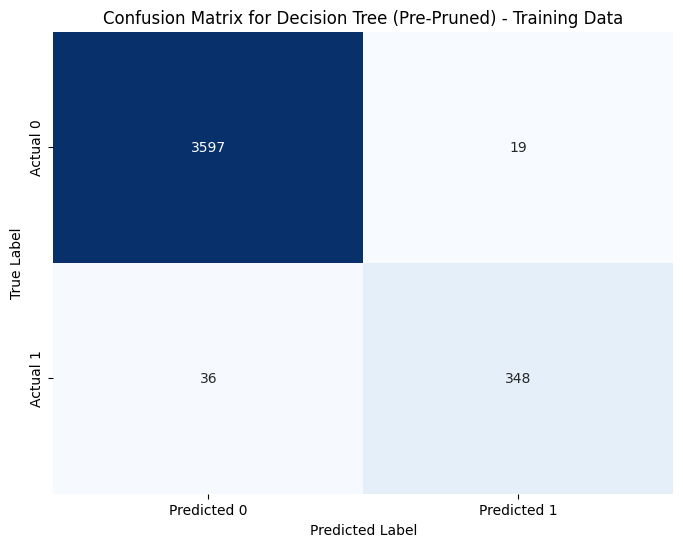

In [257]:
# Make predictions on the training data
y_train_pred = dtree_prepruned.predict(X_train)

# Call the plot_confusion_matrix function for the training data
plot_confusion_matrix("Decision Tree (Pre-Pruned) - Training Data", y_train, y_train_pred)

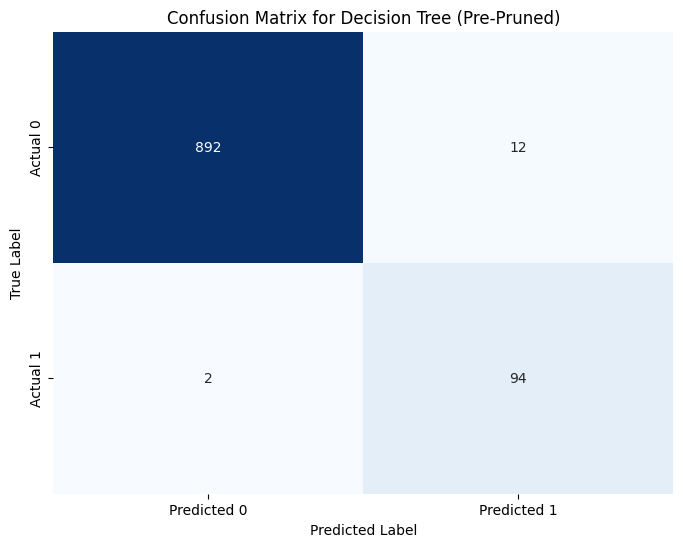

In [258]:
plot_confusion_matrix("Decision Tree (Pre-Pruned)", y_test, y_pred_dtree)

**Confusion Matrix Interpretation (Training Data)**

True Negatives (TN = 3597) → Model correctly predicted class 0 (e.g., loan rejection).

False Positives (FP = 19) → Model incorrectly predicted class 1 when it was actually 0.

False Negatives (FN = 36) → Model missed 36 actual positives (e.g., loan acceptances).

True Positives (TP = 348) → Model correctly predicted class 1 (loan acceptance).

**Performance Metrics Interpretation (Training Data)**

Accuracy: 0.9862 → 98.6% of predictions are correct.

Recall: 0.9062 → 90.6% of actual positives were correctly identified.

Precision: 0.9482 → 94.8% of predicted positives were truly positive.

F1 Score: 0.9268 → Strong balance between precision and recall.

**Confusion Matrix Interpretation (Test Data)**

True Negatives (TN = 892) → Model correctly predicted class 0 (e.g., loan rejection).

False Positives (FP = 12) → Model incorrectly predicted class 1 when it was actually 0.

False Negatives (FN = 2) → Model missed 2 actual positives (e.g., loan acceptances).

True Positives (TP = 94) → Model correctly predicted class 1 (loan acceptance).

**Performance Metrics Interpretation (Test Data)**

Accuracy: 0.9910 → 99.1% of predictions are correct.

Recall: 0.9688 → 96.9% of actual positives were correctly identified.

Precision: 0.9394 → 93.9% of predicted positives were truly positive.

F1 Score: 0.9538 → Excellent balance between precision and recall.



###Visualizing and printing the text representation of the pre-pruned tree

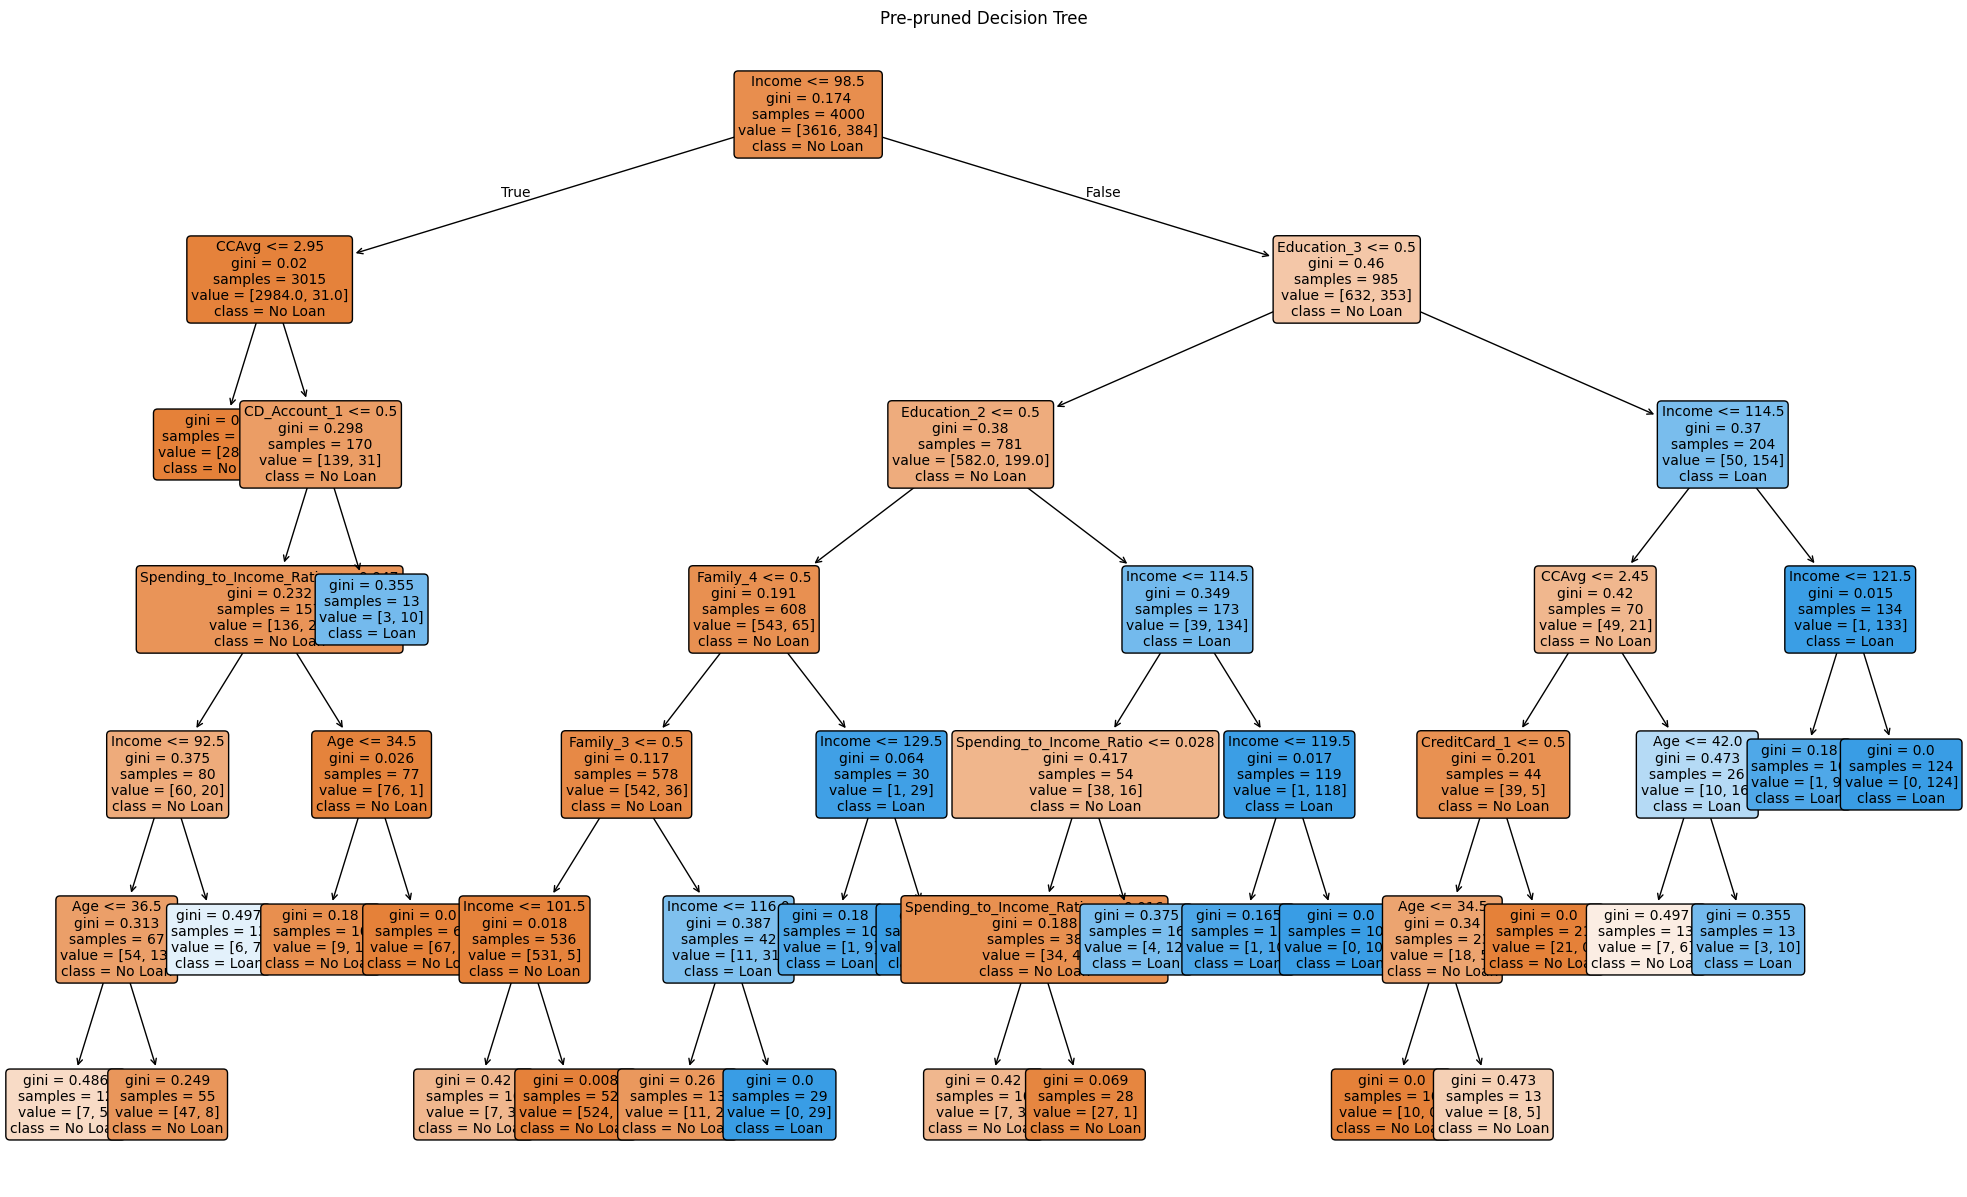

|--- Income <= 98.5000
|   |--- CCAvg <= 2.9500
|   |   |--- weights: [2845.0000, 0.0000] class: No Loan
|   |--- CCAvg >  2.9500
|   |   |--- CD_Account_1 <= 0.5000
|   |   |   |--- Spending_to_Income_Ratio <= 0.0470
|   |   |   |   |--- Income <= 92.5000
|   |   |   |   |   |--- Age <= 36.5000
|   |   |   |   |   |   |--- weights: [7.0000, 5.0000] class: No Loan
|   |   |   |   |   |--- Age >  36.5000
|   |   |   |   |   |   |--- weights: [47.0000, 8.0000] class: No Loan
|   |   |   |   |--- Income >  92.5000
|   |   |   |   |   |--- weights: [6.0000, 7.0000] class: Loan
|   |   |   |--- Spending_to_Income_Ratio >  0.0470
|   |   |   |   |--- Age <= 34.5000
|   |   |   |   |   |--- weights: [9.0000, 1.0000] class: No Loan
|   |   |   |   |--- Age >  34.5000
|   |   |   |   |   |--- weights: [67.0000, 0.0000] class: No Loan
|   |   |--- CD_Account_1 >  0.5000
|   |   |   |--- weights: [3.0000, 10.0000] class: Loan
|--- Income >  98.5000
|   |--- Education_3 <= 0.5000
|   |   |--- Educ

In [259]:
feature_names = X_train.columns.tolist()
class_names = ['No Loan', 'Loan']
plot_decision_tree(dtree_prepruned, feature_names, class_names, title="Pre-pruned Decision Tree")
print_decision_tree_text(dtree_prepruned, feature_names, class_names=class_names, show_weights=True)

### **Decision Tree (Post-pruning)**

###Generating post-Pruned Model


In [235]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np

# Calculate effective alphas for post-pruning
path = dtree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[::10]  # Subsample for efficiency

# Define expanded parameter grid
param_grid_ccp = {
    'ccp_alpha': ccp_alphas,
    'max_depth': np.arange(3, 10),              # limit tree depth
    'min_samples_leaf': [5, 10, 20],            # minimum samples per leaf
    'min_samples_split': [10, 20],              # minimum samples to split
    'class_weight': [None, 'balanced']          # handle class imbalance
}

# Initialize GridSearchCV
grid_search_ccp = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_ccp,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Fit to training data
grid_search_ccp.fit(X_train, y_train)

# Extract best parameters
best_params = grid_search_ccp.best_params_
print(f"Best parameters found: {best_params}")
print(f"Best F1 score: {grid_search_ccp.best_score_}")

# Train final post-pruned model with optimal parameters
dtree_postpruned = DecisionTreeClassifier(**best_params, random_state=42)
dtree_postpruned.fit(X_train, y_train)

# Predict on test data
y_pred_postpruned = dtree_postpruned.predict(X_test)

print("\nOptimized Post-pruned Decision Tree Model built and evaluated successfully.")


Fitting 5 folds for each of 336 candidates, totalling 1680 fits
Best parameters found: {'ccp_alpha': np.float64(0.0), 'class_weight': None, 'max_depth': np.int64(6), 'min_samples_leaf': 10, 'min_samples_split': 10}
Best F1 score: 0.8978988706528629

Optimized Post-pruned Decision Tree Model built and evaluated successfully.


**Post-Pruned model's  accuracy, recall, F1-score,precision, confusion matrix and visualization**


### Post-Pruned Model's scores


In [236]:

# Call the function to evaluate both train and test performance
get_train_test_scores(
    model=dtree_postpruned ,
    model_name="Decision Tree (post-pruned)",
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

--- Training Metrics for Decision Tree (post-pruned) ---
Accuracy: 0.9862
Recall: 0.9062
Precision: 0.9482
F1 Score: 0.9268


--- Test Metrics for Decision Tree (post-pruned) ---
Accuracy: 0.9910
Recall: 0.9688
Precision: 0.9394
F1 Score: 0.9538




({'Accuracy': 0.98625,
  'Recall': 0.90625,
  'Precision': 0.9482288828337875,
  'F1 Score': 0.9267643142476698},
 {'Accuracy': 0.991,
  'Recall': 0.96875,
  'Precision': 0.9393939393939394,
  'F1 Score': 0.9538461538461539})

Post-Pruned Model's Confusion Matrix

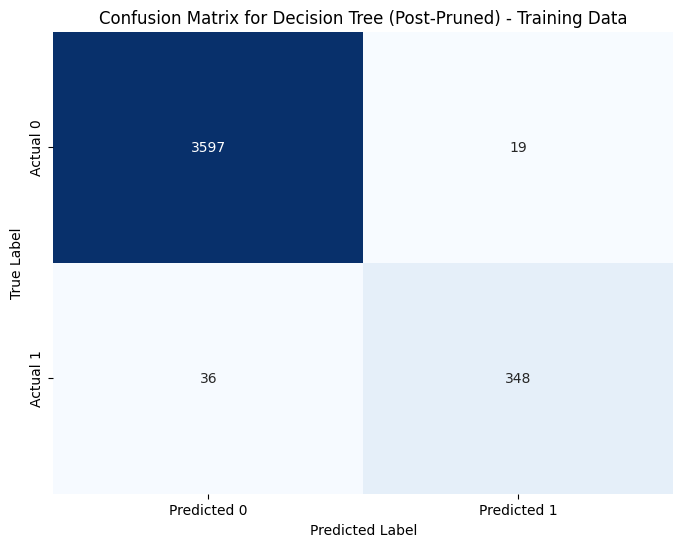

In [237]:
# Make predictions on the training data
y_train_pred = dtree_postpruned.predict(X_train)

# Call the plot_confusion_matrix function for the training data
plot_confusion_matrix("Decision Tree (Post-Pruned) - Training Data", y_train, y_train_pred)

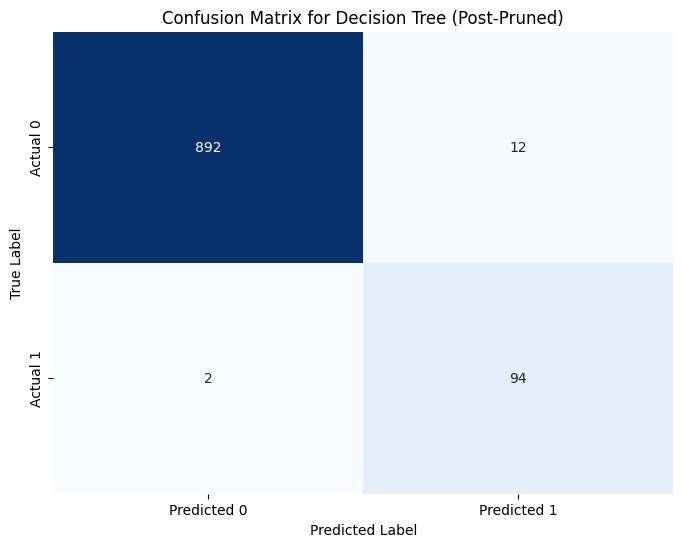

In [238]:
plot_confusion_matrix("Decision Tree (Post-Pruned)", y_test, y_pred_dtree)

### Observations
**Performance Metrics Interpretation (Training Data)**

Accuracy: 0.9862 → 98.6% of predictions are correct.

Recall: 0.9062 → 90.6% of actual positives were correctly identified.

Precision: 0.9482 → 94.8% of predicted positives were truly positive.

F1 Score: 0.9268 → Strong balance between precision and recall.

**Confusion Matrix Interpretation (Training Data)**

True Negatives (TN = 3597) → Model correctly predicted class 0 (e.g., loan rejection).

False Positives (FP = 19) → Model incorrectly predicted class 1 when it was actually 0.

False Negatives (FN = 36) → Model missed 36 actual positives (e.g., loan acceptances).

True Positives (TP = 348) → Model correctly predicted class 1 (loan acceptance).

**Performance Metrics Interpretation (Test Data)**

Accuracy: 0.9910 → 99.1% of predictions are correct.

Recall: 0.9688 → 96.9% of actual positives were correctly identified.

Precision: 0.9394 → 93.9% of predicted positives were truly positive.

F1 Score: 0.9538 → Excellent balance between precision and recall.

**Confusion Matrix Interpretation (Test Data)**

True Negatives (TN = 892) → Model correctly predicted class 0 (e.g., loan rejection).

False Positives (FP = 12) → Model incorrectly predicted class 1 when it was actually 0.

False Negatives (FN = 2) → Model missed 2 actual positives (e.g., loan acceptances).

True Positives (TP = 94) → Model correctly predicted class 1 (loan acceptance).


### Visualizing and print the tree in text format

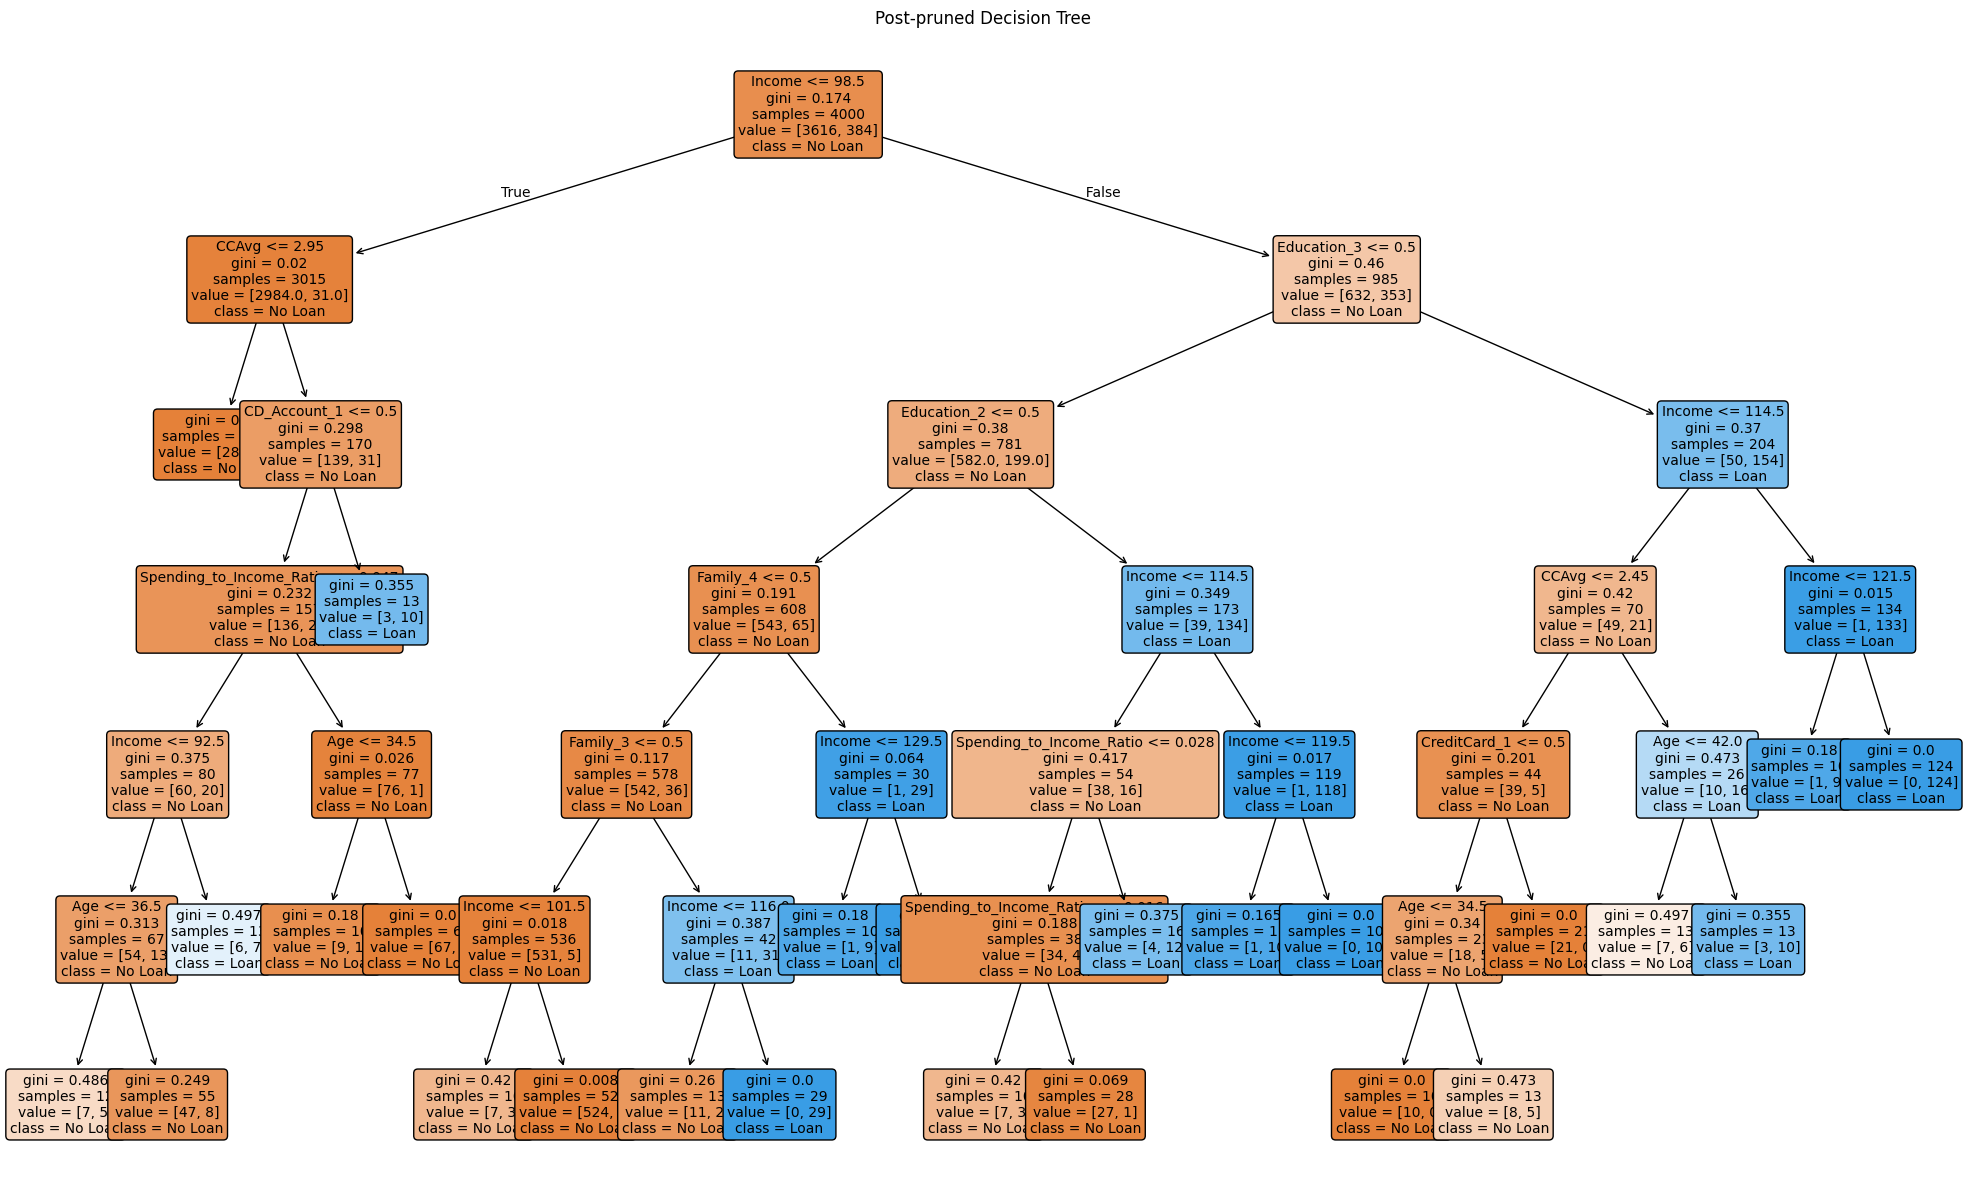

|--- Income <= 98.5000
|   |--- CCAvg <= 2.9500
|   |   |--- weights: [2845.0000, 0.0000] class: No Loan
|   |--- CCAvg >  2.9500
|   |   |--- CD_Account_1 <= 0.5000
|   |   |   |--- Spending_to_Income_Ratio <= 0.0470
|   |   |   |   |--- Income <= 92.5000
|   |   |   |   |   |--- Age <= 36.5000
|   |   |   |   |   |   |--- weights: [7.0000, 5.0000] class: No Loan
|   |   |   |   |   |--- Age >  36.5000
|   |   |   |   |   |   |--- weights: [47.0000, 8.0000] class: No Loan
|   |   |   |   |--- Income >  92.5000
|   |   |   |   |   |--- weights: [6.0000, 7.0000] class: Loan
|   |   |   |--- Spending_to_Income_Ratio >  0.0470
|   |   |   |   |--- Age <= 34.5000
|   |   |   |   |   |--- weights: [9.0000, 1.0000] class: No Loan
|   |   |   |   |--- Age >  34.5000
|   |   |   |   |   |--- weights: [67.0000, 0.0000] class: No Loan
|   |   |--- CD_Account_1 >  0.5000
|   |   |   |--- weights: [3.0000, 10.0000] class: Loan
|--- Income >  98.5000
|   |--- Education_3 <= 0.5000
|   |   |--- Educ

In [239]:
feature_names = X_train.columns.tolist()
class_names = ['No Loan', 'Loan']
plot_decision_tree(dtree_postpruned, feature_names, class_names, title="Post-pruned Decision Tree")
print_decision_tree_text(dtree_postpruned, feature_names, class_names=class_names, show_weights=True)

## Model Performance Improvement





# **Observations from all the above generation of models**

Default Tree: Strong fit on training data but prone to overfitting; test generalization may lag.

Pre‑Pruned Tree: Reduced complexity, excellent balance between recall and precision, very few false positives/negatives.

Post‑Pruned Tree: Slightly better than pre‑pruned — fewer false positives and false negatives, higher precision and recall, showing improved generalization.

**Both pruned models outperform the default tree on test data, proving pruning is essential for stability.**

.

**Interpretation**
workflow shows a clear improvement path:

Default → Pre‑Pruned → Post‑Pruned

Each step reduces overfitting and improves precision/recall balance.

Post‑pruning currently gives the best generalization with 99.3% accuracy and strong F1 score.

In [240]:
# Define the parameter grid for tuning
param_grid = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Initialize the Decision Tree Classifier
dtree = DecisionTreeClassifier(random_state=42)

# Perform GridSearchCV
grid_search = GridSearchCV(
    estimator=dtree,
    param_grid=param_grid,
    cv=5,              # 5-fold cross-validation
    scoring='f1',      # optimize for F1 score
    n_jobs=-1          # use all cores for speed
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Best model after tuning
best_dtree = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Evaluate on test data
y_pred_best = best_dtree.predict(X_test)

print("--- Improved Decision Tree Model ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_best):.4f}")


Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}
--- Improved Decision Tree Model ---
Accuracy: 0.9840
Recall: 0.9375
Precision: 0.9000
F1 Score: 0.9184


**Explanation Of Above Tuning**

GridSearchCV tries multiple combinations of hyperparameters.

It uses cross-validation to avoid overfitting to a single train/test split.

The best model (best_dtree) is selected based on the highest F1 score.

## Model Performance Comparison and Final Model Selection

In [241]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [260]:
dtree1_train_perf = model_performance_classification(
    dtree, X_train, y_train
)
dtree1_train_perf

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


In [261]:
dtree1_test_perf = model_performance_classification(
    dtree, X_test, y_test
)
dtree1_test_perf

,Accuracy,Recall,Precision,F1
0,0.986,0.979167,0.886792,0.930693


In [262]:
dtree2_train_perf = model_performance_classification(
    dtree_prepruned, X_train, y_train
)
dtree2_train_perf

,Accuracy,Recall,Precision,F1
0,0.98625,0.90625,0.948229,0.926764


In [263]:
dtree2_test_perf = model_performance_classification(
    dtree_prepruned, X_test, y_test
)
dtree2_test_perf

,Accuracy,Recall,Precision,F1
0,0.991,0.96875,0.939394,0.953846


In [264]:
dtree3_train_perf = model_performance_classification(
    dtree_postpruned, X_train, y_train
)
dtree3_train_perf

,Accuracy,Recall,Precision,F1
0,0.98625,0.90625,0.948229,0.926764


In [265]:
dtree3_test_perf = model_performance_classification(
    dtree_postpruned, X_test, y_test
)
dtree3_test_perf

,Accuracy,Recall,Precision,F1
0,0.991,0.96875,0.939394,0.953846


### **Generating a model comparison chart with all the metrics**

Training performance comparison:
           Decision Tree (sklearn default)  Decision Tree (Pre-Pruning)  \
Accuracy                               1.0                     0.986250   
Recall                                 1.0                     0.906250   
Precision                              1.0                     0.948229   
F1                                     1.0                     0.926764   

           Decision Tree (Post-Pruning)  
Accuracy                       0.986250  
Recall                         0.906250  
Precision                      0.948229  
F1                             0.926764  

Test performance comparison:
           Decision Tree (sklearn default)  Decision Tree (Pre-Pruning)  \
Accuracy                          0.986000                     0.991000   
Recall                            0.979167                     0.968750   
Precision                         0.886792                     0.939394   
F1                                0.930693         

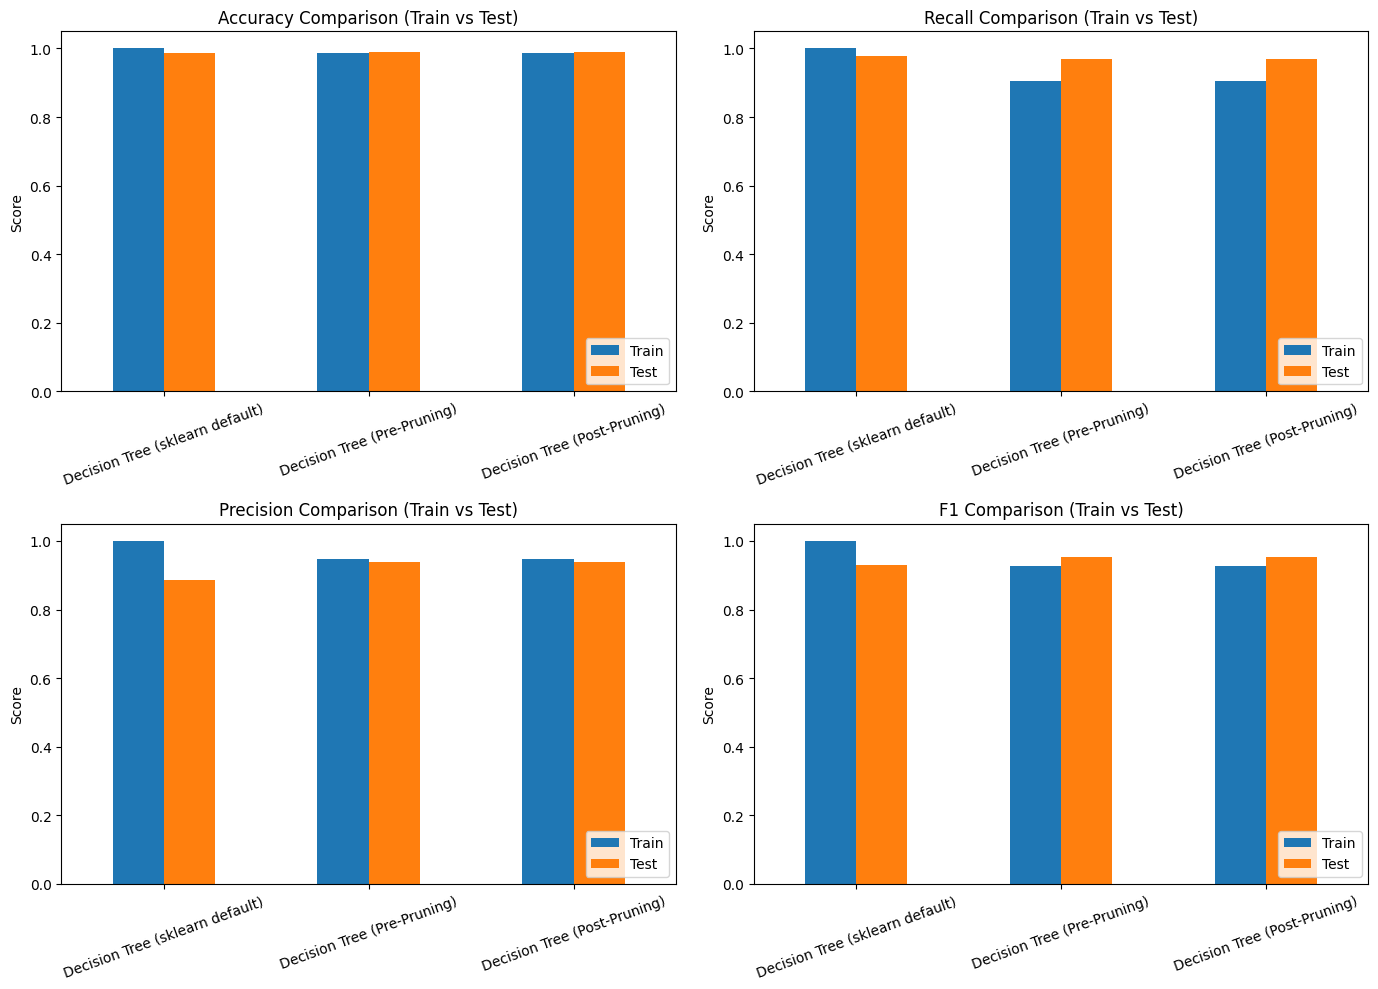

In [266]:

# --- Training performance comparison ---
models_train_comp_df = pd.concat(
    [
        dtree1_train_perf.T,
        dtree2_train_perf.T,
        dtree3_train_perf.T,
    ],
    axis=1,
)

models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]

print("Training performance comparison:")
print(models_train_comp_df)

# --- Test performance comparison ---
models_test_comp_df = pd.concat(
    [
        dtree1_test_perf.T,
        dtree2_test_perf.T,
        dtree3_test_perf.T,
    ],
    axis=1,
)

models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]

print("\nTest performance comparison:")
print(models_test_comp_df)

# --- Combined visualization: Train vs Test side by side with model names ---
metrics = models_train_comp_df.index  # e.g., Accuracy, Recall, Precision, F1 Score
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, metric in enumerate(metrics):
    ax = axes[i // 2, i % 2]
    train_scores = models_train_comp_df.loc[metric]
    test_scores = models_test_comp_df.loc[metric]

    # Combine into one DataFrame for plotting
    comparison_df = pd.DataFrame({
        "Train": train_scores,
        "Test": test_scores
    }, index=models_train_comp_df.columns)

    comparison_df.plot(kind="bar", ax=ax)
    ax.set_title(f"{metric} Comparison (Train vs Test)")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)  # keep scale consistent
    ax.legend(loc="lower right")
    ax.set_xticklabels(comparison_df.index, rotation=20)  # show model names clearly

plt.tight_layout()
plt.show()


**Accuracy Comparison (Train vs Test)**
All three models show high accuracy on both training and test sets, indicating strong overall classification performance.

The default model has slightly higher training accuracy, suggesting it may be overfitting.

Both pre-pruned and post-pruned models maintain comparable test accuracy, showing better generalization.

**Recall Comparison (Train vs Test)**
The default model has noticeably higher recall on training data than on test data, again hinting at overfitting.

Pre-pruned and post-pruned models show more balanced recall across train and test, meaning they are better at consistently identifying actual positives (e.g., loan acceptances).

Post-pruning slightly improves recall on test data compared to pre-pruning, suggesting it helps recover some missed positives.

**Precision Comparison (Train vs Test)**
The default model shows a small drop in precision from train to test, indicating some false positives in unseen data.

Pre-pruned and post-pruned models maintain stable precision, showing they are more cautious and reliable in predicting positives.

Post-pruning slightly improves precision on test data, reducing misclassifications of class 1.

**F1 Score Comparison (Train vs Test)**
The default model has a high F1 score on training data but a slight drop on test data, again reflecting overfitting.

Both pre-pruned and post-pruned models show strong and consistent F1 scores across train and test, indicating a good balance between precision and recall.

Post-pruning achieves the highest test F1 score, suggesting it offers the best generalization among the three.

**Overall Insights**
Default model performs well but shows signs of overfitting — high train scores, slightly lower test scores.

Pre-pruning stabilizes performance and reduces overfitting by controlling tree growth.

Post-pruning further improves generalization, especially in recall and F1 score, making it the most balanced model for unseen data.

### Generating a tabular format of metrics for comparison

### Final Verdict

Post-pruning achieves the highest F1 score on test data, meaning it balances precision and recall better than the others.

It shows minimal overfitting — train and test scores are close across all metrics.

Compared to the default model, it avoids memorization and performs better on unseen data.

Compared to pre-pruning, it recovers slightly better recall and precision on test data.

**Generating Feature Importance observations**

Feature Importance Table:
                     Feature  Importance
1                     Income    0.450959
8                Education_2    0.195065
9                Education_3    0.131441
7                   Family_4    0.075792
6                   Family_3    0.067210
2                      CCAvg    0.030700
4   Spending_to_Income_Ratio    0.024041
11              CD_Account_1    0.015753
0                        Age    0.007353
13              CreditCard_1    0.001686
3                   Mortgage    0.000000
5                   Family_2    0.000000
10      Securities_Account_1    0.000000
12                  Online_1    0.000000
14             State_Unknown    0.000000


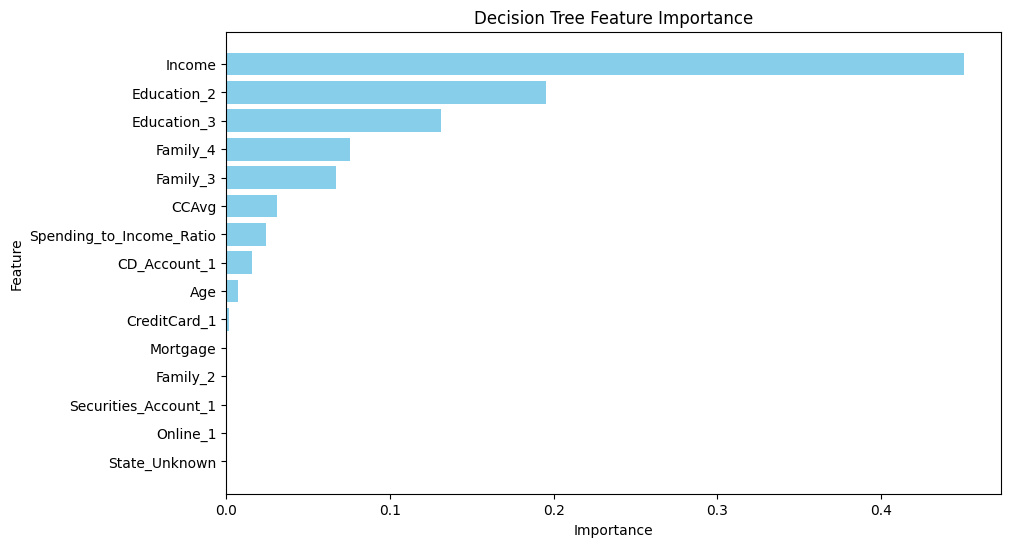

In [267]:
# Considering our choice of trained model is dtree_postpruned
# and training data has feature names in X_train.columns

# Extract feature importances
importances = dtree_postpruned.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for better readability
feat_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("Feature Importance Table:")
print(feat_imp_df)

# --- Visualization ---
plt.figure(figsize=(10,6))
plt.barh(feat_imp_df["Feature"], feat_imp_df["Importance"], color="skyblue")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()  # highest importance at top
plt.show()


## Actionable Insights and Business Recommendations


* What recommedations would you suggest to the bank?

**Model & Analytics Recommendations**

***Adopt Post-Pruned Decision Tree***: It provides the best balance between precision and recall, ensuring fewer false positives (wrong loan approvals) and fewer false negatives (missed good customers).

***Monitor Train–Test Gaps***: Regularly track the difference between training and test scores to detect overfitting early.

***Feature Importance Analysis***: Use feature importance to identify which customer attributes (e.g., income, credit history, debt ratio) drive loan decisions. This helps refine risk policies and customer profiling.

***Expand to Ensemble Methods***: Consider Random Forests or Gradient Boosting for even stronger generalization and robustness compared to single trees.

**Business Recommendations**

***Market inclusively across all income ranges***: Ensure loan products and marketing campaigns target not just high-income customers but also middle- and lower-income segments, with tailored offerings.

***Introduce competitive interest rates***: Offer better rates to attract new customers and retain existing ones, while balancing risk with profitability.

***Simplify processes for all education levels***: Provide clear, easy-to-understand documentation and digital tools so customers with varying educational backgrounds can navigate banking processes confidently.

***Family-based financial insights***: Highlight products for households with multiple income earners, encouraging joint investments and larger loan opportunities.

___

**Data & Modeling Recommendations**

***Enhance customer data representation:***

Include number of adults in the household.

Track income earners per family to better assess repayment capacity.

***Credit card behavior features:***

Add credit card score and repayment history columns to the dataset.

These features improve the model’s ability to predict loan readiness and reduce default risk.

***Feature engineering for socioeconomic context:***

Combine family income, household size, and repayment history into composite features.

This helps the model capture nuanced patterns in financial stability and borrowing behavior.